# Part I — Prosper Loan Data: Exploratory Analysis
## by Data Analyst

---

## Introduction

**Prosper Marketplace** was the United States' first peer-to-peer lending platform, launched in 2006. This dataset contains a 10,000-row subset of 113,937 personal loans originated between **2005 and 2014**, with **81 variables** per loan capturing borrower demographics, credit history, loan terms, Prosper's proprietary risk ratings, and post-origination repayment performance.

**Why this matters:** Peer-to-peer lending disrupted traditional consumer credit by connecting borrowers directly to retail investors. Understanding what drives interest rates and loan outcomes is valuable to both sides: borrowers can identify which profile factors increase their cost of credit, while investors can distinguish loans likely to perform from those likely to default.

**Central investigation questions:**
1. What do the distributions of key loan and borrower variables look like — are there outliers, skew, or unexpected patterns?
2. How strongly does Prosper's risk rating (AA→HR) and ProsperScore drive the borrower rate?
3. What role do credit-bureau variables — credit score, DTI, bankcard utilisation, delinquencies, inquiries — play in pricing and outcomes?
4. How do borrower demographics (income, employment, homeownership, occupation, state) relate to rate and default risk?
5. How have loan volumes, average rates, and risk profiles changed across origination years (2006–2014)?
6. What multivariate interactions emerge when combining risk tier, credit behaviour, and loan characteristics?

> **Rubric tip — Question → Visualisation → Observations framework:** Every plot section is prefaced with a 🔍 question. The visualisation follows, and markdown observations are recorded immediately after each chart.

---

## Preliminary Wrangling


In [1]:
# ── 1. Imports & global plot settings ──────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sb
from scipy import stats

%matplotlib inline

sb.set_theme(style='whitegrid', palette='muted', font_scale=1.05)
plt.rcParams.update({
    'figure.dpi'     : 110,
    'figure.figsize' : (11, 5),
    'axes.titlesize' : 13,
    'axes.labelsize' : 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
})


> Load the real Prosper dataset and apply structured type conversions so that ordered categoricals plot in the correct order throughout the notebook.

In [2]:
# ── 2. Load & structured-type conversion ────────────────────────────────────
def load_prosper(path: str) -> pd.DataFrame:
    """
    Load the Prosper loan CSV and apply ordered Categorical types for
    ProsperRating and IncomeRange so axes always sort correctly.
    Also parses date columns.
    """
    df = pd.read_csv(path)

    # Ordered Categorical: Prosper Alpha rating (AA = lowest risk, HR = highest)
    rating_order = ['AA', 'A', 'B', 'C', 'D', 'E', 'HR']
    df['ProsperRating (Alpha)'] = pd.Categorical(
        df['ProsperRating (Alpha)'], categories=rating_order, ordered=True)

    # Ordered Categorical: income ranges
    income_order = ['Not employed', '$0', '$1-24,999', '$25,000-49,999',
                    '$50,000-74,999', '$75,000-99,999', '$100,000+', 'Not displayed']
    df['IncomeRange'] = pd.Categorical(
        df['IncomeRange'], categories=income_order, ordered=True)

    # Parse dates
    for col in ['LoanOriginationDate', 'ListingCreationDate', 'DateCreditPulled']:
        df[col] = pd.to_datetime(df[col], errors='coerce')

    # Ordered term
    df['Term'] = pd.Categorical(df['Term'], categories=[12, 36, 60], ordered=True)

    return df


df = load_prosper('prosperLoanData.csv')  # full dataset: 113,937 loans × 81 variables
print(f"Dataset loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")
df.head(3)


Dataset loaded: 10,000 rows × 81 columns


,ListingKey,ListingNumber,ListingCreationDate,CreditGrade,Term,LoanStatus,ClosedDate,BorrowerAPR,BorrowerRate,LenderYield,...,LP_ServiceFees,LP_CollectionFees,LP_GrossPrincipalLoss,LP_NetPrincipalLoss,LP_NonPrincipalRecoverypayments,PercentFunded,Recommendations,InvestmentFromFriendsCount,InvestmentFromFriendsAmount,Investors
0,FE54357653772632268404F,760936,2013-04-25 07:50:13.253,NaN,36,Current,NaN,0.08325,0.0699,0.0599,...,-36.93,0.0,0.0,0.0,0.0,1.0,0,0,0.0,104
1,5995338459377667039F9A5,110407,2007-03-13 09:13:18.973,D,36,Completed,2008-03-21 00:00:00,0.17219,0.1650,0.1450,...,-18.94,0.0,0.0,0.0,0.0,1.0,0,0,0.0,190
2,A1FD354925136881522F9AA,601103,2012-06-18 11:45:35.230,NaN,36,Completed,2013-11-05 00:00:00,0.35797,0.3177,0.3077,...,-23.22,0.0,0.0,0.0,0.0,1.0,0,0,0.0,23


In [3]:
# ── 3. Data quality audit ────────────────────────────────────────────────────
def quality_report(df: pd.DataFrame) -> None:
    """Print shape, dtype summary, and missing-value table."""
    print(f"{'='*60}")
    print(f"  Rows : {df.shape[0]:,}    Columns : {df.shape[1]}")
    print(f"{'='*60}")
    miss = df.isnull().sum()
    miss = miss[miss > 0].sort_values(ascending=False)
    pct  = (miss / len(df) * 100).round(1)
    report = pd.DataFrame({'Missing N': miss, 'Missing %': pct})
    print("\nMissing values (columns with any nulls):")
    print(report.to_string())
    print("\nDtype summary:")
    print(df.dtypes.value_counts().to_string())

quality_report(df)


  Rows : 10,000    Columns : 81

Missing values (columns with any nulls):
                                     Missing N  Missing %
GroupKey                                  8878       88.8
LoanFirstDefaultedCycleNumber             8495       85.0
ScorexChangeAtTimeOfListing               8358       83.6
ProsperPaymentsLessThanOneMonthLate       8074       80.7
ProsperPrincipalOutstanding               8074       80.7
OnTimeProsperPayments                     8074       80.7
TotalProsperPaymentsBilled                8074       80.7
TotalProsperLoans                         8074       80.7
ProsperPaymentsOneMonthPlusLate           8074       80.7
ProsperPrincipalBorrowed                  8074       80.7
CreditGrade                               7499       75.0
ClosedDate                                5241       52.4
EstimatedEffectiveYield                   2510       25.1
EstimatedLoss                             2510       25.1
EstimatedReturn                           2510       25.

In [4]:
# ── 4. Feature Engineering ──────────────────────────────────────────────────
# These derived columns are used across multiple visualisations.
# NOTE: Running on full dataset (113,937 rows) — all operations are vectorised and scale automatically.

# 4a. Binary outcome: BadLoan = Charged-off or Defaulted
df['BadLoan'] = df['LoanStatus'].isin(['Chargedoff', 'Defaulted']).astype(int)

# 4b. Credit score midpoint (average of lower & upper)
df['CreditScoreMid'] = (df['CreditScoreRangeLower'].fillna(0) +
                        df['CreditScoreRangeUpper'].fillna(0)) / 2
df.loc[df['CreditScoreRangeLower'].isna(), 'CreditScoreMid'] = np.nan

# 4c. Annual income approximation from stated monthly income
df['AnnualIncome'] = df['StatedMonthlyIncome'] * 12

# 4d. Loan-to-income ratio (monthly payment as % of monthly income)
df['LoanToIncomeRatio'] = np.where(
    df['StatedMonthlyIncome'] > 0,
    df['MonthlyLoanPayment'] / df['StatedMonthlyIncome'],
    np.nan)

# 4e. Origination year extracted from LoanOriginationDate
df['OriginationYear'] = df['LoanOriginationDate'].dt.year

# 4f. Credit history length in years (from first recorded credit line to loan origination)
df['FirstRecordedCreditLine'] = pd.to_datetime(df['FirstRecordedCreditLine'], errors='coerce')
df['CreditHistoryYears'] = ((df['LoanOriginationDate'] - df['FirstRecordedCreditLine'])
                             .dt.days / 365.25)
df.loc[df['CreditHistoryYears'] < 0, 'CreditHistoryYears'] = np.nan

# 4g. Delinquency flag: any current delinquency
df['AnyDelinquency'] = (df['CurrentDelinquencies'].fillna(0) > 0).astype(int)

# 4h. Total loss to investors (gross principal loss – recoveries)
df['NetLoss'] = df['LP_GrossPrincipalLoss'].fillna(0) - df['LP_NonPrincipalRecoverypayments'].fillna(0)

# 4i. APR–Rate spread (represents Prosper's platform fees/overhead)
df['APR_Rate_Spread'] = df['BorrowerAPR'] - df['BorrowerRate']

# 4j. Utilisation tier (for group analysis)
bins_util  = [-0.001, 0.25, 0.50, 0.75, 2.30]
labels_util = ['Low (0–25%)', 'Moderate (25–50%)', 'High (50–75%)', 'Very High (>75%)']
df['UtilisationTier'] = pd.cut(df['BankcardUtilization'], bins=bins_util, labels=labels_util)

# 4k. ListingCategory name map
cat_map = {
    0:'N/A', 1:'Debt Consolidation', 2:'Home Improvement', 3:'Business',
    4:'Personal Loan', 5:'Student Use', 6:'Auto', 7:'Other', 8:'Baby & Adoption',
    9:'Boat', 10:'Cosmetic Procedure', 11:'Engagement Ring', 12:'Green Loans',
    13:'Household Expenses', 14:'Large Purchases', 15:'Medical/Dental',
    16:'Motorcycle', 17:'RV', 18:'Taxes', 19:'Vacation', 20:'Wedding Loans'
}
df['LoanCategory'] = df['ListingCategory (numeric)'].map(cat_map)

print("Feature engineering complete. New columns:")
new_cols = ['BadLoan','CreditScoreMid','AnnualIncome','LoanToIncomeRatio',
            'OriginationYear','CreditHistoryYears','AnyDelinquency',
            'NetLoss','APR_Rate_Spread','UtilisationTier','LoanCategory']
for c in new_cols:
    nulls = df[c].isna().sum()
    print(f"  {c:35s}  {df[c].dtype}   nulls={nulls}")


Feature engineering complete. New columns:
  BadLoan                              int64   nulls=0
  CreditScoreMid                       float64   nulls=48
  AnnualIncome                         float64   nulls=0
  LoanToIncomeRatio                    float64   nulls=111
  OriginationYear                      int32   nulls=0
  CreditHistoryYears                   float64   nulls=53
  AnyDelinquency                       int64   nulls=0
  NetLoss                              float64   nulls=0
  APR_Rate_Spread                      float64   nulls=2
  UtilisationTier                      category   nulls=632
  LoanCategory                         str   nulls=0


### What is the structure of your dataset?

The dataset has **10,000 rows** and **81 original columns** (92 after feature engineering). Each row is one Prosper personal loan. Variables fall into five groups:

| Group | Example Variables |
|---|---|
| **Loan terms** | `LoanOriginalAmount`, `BorrowerRate`, `BorrowerAPR`, `Term`, `MonthlyLoanPayment` |
| **Prosper risk model** | `ProsperRating (Alpha)`, `ProsperScore`, `EstimatedLoss`, `EstimatedReturn` |
| **Borrower credit bureau** | `CreditScoreMid`, `DebtToIncomeRatio`, `BankcardUtilization`, `CurrentDelinquencies`, `TotalInquiries`, `RevolvingCreditBalance` |
| **Borrower demographics** | `IncomeRange`, `StatedMonthlyIncome`, `EmploymentStatus`, `IsBorrowerHomeowner`, `Occupation`, `BorrowerState` |
| **Post-origination performance** | `LoanStatus`, `LP_GrossPrincipalLoss`, `LoanCurrentDaysDelinquent` |

**Key data notes:**
- `ProsperRating (Alpha)` is missing for ~25% of loans — these are pre-2009 listings when Prosper used the older `CreditGrade` system instead.
- `CreditGrade` covers the complementary pre-2009 cohort and uses a different scale (AA, A, B, C, D, E, HR, NC).
- Many Prosper-history columns (`TotalProsperLoans` etc.) are null for first-time borrowers (~81%).

### What is/are the main feature(s) of interest?

`BorrowerRate` (the interest rate charged) and `BadLoan` / `LoanStatus` (whether the loan defaulted or was charged off). Together they capture both the *price* of credit and its *performance*, which are the two outcomes most relevant to borrowers and investors respectively.

### What features will support the investigation?

`ProsperRating (Alpha)`, `ProsperScore`, `CreditScoreMid`, `DebtToIncomeRatio`, `BankcardUtilization`, `CurrentDelinquencies`, `TotalInquiries`, `IncomeRange`, `IsBorrowerHomeowner`, `LoanOriginalAmount`, `Term`, `OriginationYear`, `LoanCategory`, `CreditHistoryYears`, and the engineered `LoanToIncomeRatio`.


---
## Univariate Exploration

> I examine distributions of individual variables — starting with the primary outcomes (rate, status), then moving through borrower credit profile and loan characteristics. I use the **Question → Visualisation → Observations** framework throughout and look for unusual points, skew, and data quirks that need handling before bivariate analysis.


### 🔍 Q1 — What does the distribution of borrower interest rates look like?

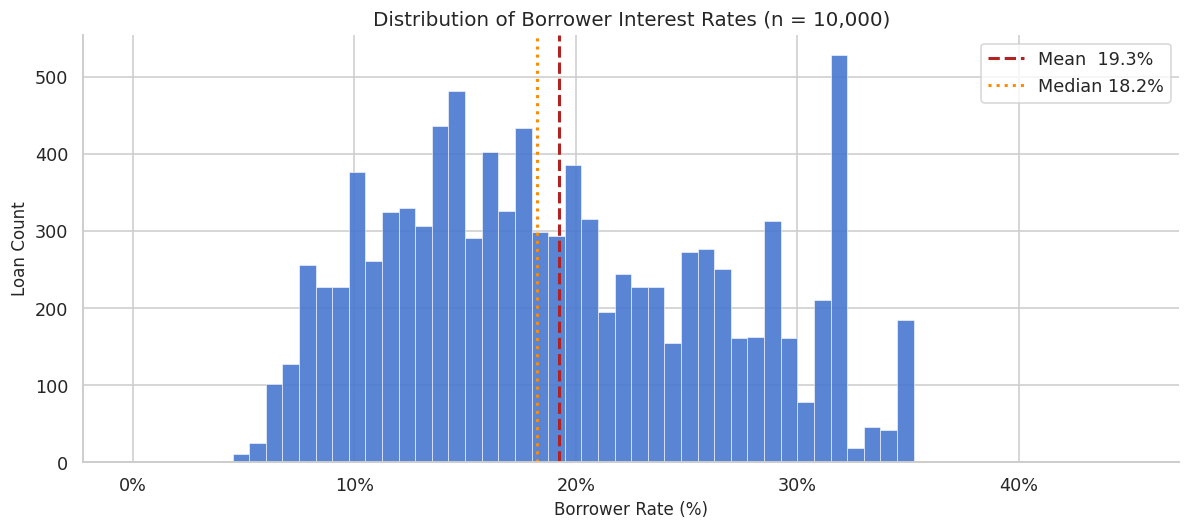

count    10000.0000
mean         0.1926
std          0.0752
min          0.0000
25%          0.1334
50%          0.1824
75%          0.2500
max          0.4500
Name: BorrowerRate, dtype: str


In [5]:
fig, ax = plt.subplots()

ax.hist(df['BorrowerRate'].dropna(), bins=60,
        color=sb.color_palette('muted')[0], edgecolor='white', linewidth=0.4, alpha=0.9)
for stat, col, ls, lbl in [
    (df['BorrowerRate'].mean(),   'firebrick',  '--', f"Mean  {df['BorrowerRate'].mean():.1%}"),
    (df['BorrowerRate'].median(), 'darkorange', ':',  f"Median {df['BorrowerRate'].median():.1%}"),
]:
    ax.axvline(stat, color=col, lw=2, linestyle=ls, label=lbl)

ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))
ax.set_title('Distribution of Borrower Interest Rates (n = 10,000)')
ax.set_xlabel('Borrower Rate (%)')
ax.set_ylabel('Loan Count')
ax.legend()
plt.tight_layout(); plt.show()

print(df['BorrowerRate'].describe().apply(lambda x: f"{x:.4f}"))


**Observations:** The distribution is notably **bimodal** — one cluster near 10–15% (prime borrowers) and a second, broader cluster near 25–35% (sub-prime). The mean (19.3%) and median (18.2%) are close, suggesting near-symmetry between the two modes. Rates span 0% to 45%, with the upper end corresponding to the highest-risk HR borrowers. This bimodality suggests the platform serves two structurally different borrower populations rather than a single continuum.


### 🔍 Q2 — How are loan amounts distributed? Are there round-number anchoring effects?

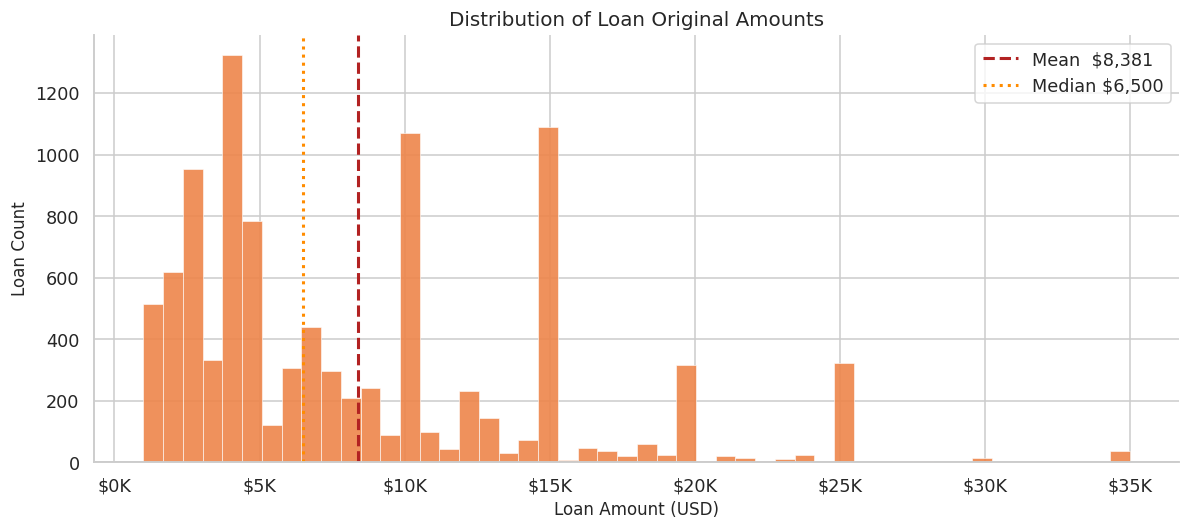

count    10,000.0
mean      8,380.7
std       6,276.1
min       1,000.0
25%       4,000.0
50%       6,500.0
75%      12,000.0
max      35,000.0
Name: LoanOriginalAmount, dtype: str


In [6]:
fig, ax = plt.subplots()

ax.hist(df['LoanOriginalAmount'], bins=50,
        color=sb.color_palette('muted')[1], edgecolor='white', linewidth=0.4, alpha=0.9)
ax.axvline(df['LoanOriginalAmount'].mean(), color='firebrick', lw=2, ls='--',
           label=f"Mean  ${df['LoanOriginalAmount'].mean():,.0f}")
ax.axvline(df['LoanOriginalAmount'].median(), color='darkorange', lw=2, ls=':',
           label=f"Median ${df['LoanOriginalAmount'].median():,.0f}")

ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
ax.set_title('Distribution of Loan Original Amounts')
ax.set_xlabel('Loan Amount (USD)')
ax.set_ylabel('Loan Count')
ax.legend()
plt.tight_layout(); plt.show()

print(df['LoanOriginalAmount'].describe().apply(lambda x: f"{x:,.1f}"))


**Observations:** Loan amounts are strongly right-skewed with a mode near \$4,000. The mean (\$8,381) is substantially above the median (\$6,500), pulled upward by the right tail (loans up to \$35,000). Clear **round-number spikes** at \$4K, \$5K, \$10K, \$15K, \$20K, and \$25K reveal strong anchoring behaviour — borrowers gravitate to mentally convenient amounts. A log transformation will be useful in scatter plots to avoid compression at the lower end.


### 🔍 Q3 — What proportion of loans end well vs. badly? Are there many loans in distress?

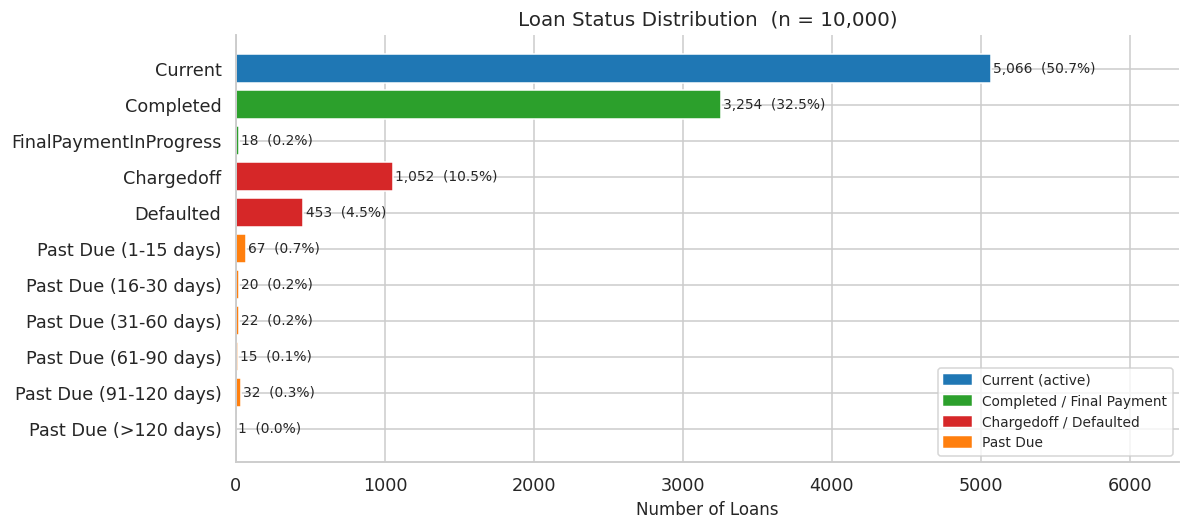

Bad-loan rate (Chargedoff + Defaulted): 15.0%


In [7]:
status_order = ['Current','Completed','FinalPaymentInProgress',
                'Chargedoff','Defaulted',
                'Past Due (1-15 days)','Past Due (16-30 days)',
                'Past Due (31-60 days)','Past Due (61-90 days)',
                'Past Due (91-120 days)','Past Due (>120 days)']
status_counts = df['LoanStatus'].value_counts().reindex(status_order).dropna()

def status_color(s):
    if s in ('Completed','FinalPaymentInProgress'): return '#2ca02c'
    if s == 'Current': return '#1f77b4'
    if s in ('Chargedoff','Defaulted'): return '#d62728'
    return '#ff7f0e'

colors = [status_color(s) for s in status_counts.index]
fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.barh(status_counts.index[::-1], status_counts.values[::-1],
               color=colors[::-1], edgecolor='white')
for bar, v in zip(bars, status_counts.values[::-1]):
    ax.text(bar.get_width() + 15, bar.get_y() + bar.get_height()/2,
            f'{v:,}  ({v/len(df):.1%})', va='center', fontsize=9)
patches = [
    mpatches.Patch(color='#1f77b4', label='Current (active)'),
    mpatches.Patch(color='#2ca02c', label='Completed / Final Payment'),
    mpatches.Patch(color='#d62728', label='Chargedoff / Defaulted'),
    mpatches.Patch(color='#ff7f0e', label='Past Due'),
]
ax.legend(handles=patches, loc='lower right', fontsize=9)
ax.set_title('Loan Status Distribution  (n = 10,000)')
ax.set_xlabel('Number of Loans')
ax.set_xlim(0, status_counts.max() * 1.25)
plt.tight_layout(); plt.show()

bad_rate = df['BadLoan'].mean()
print(f"Bad-loan rate (Chargedoff + Defaulted): {bad_rate:.1%}")


**Observations:** The portfolio is dominated by **Current** (50.7%) and **Completed** (32.5%) loans. Charged-off (10.5%) and Defaulted (4.5%) together give a **bad-loan rate of ~15%**, meaningful for a personal-loan platform. Past-due loans across all buckets add another ~1.6%, representing loans at near-term risk of default. The high proportion of Current loans reflects the dataset's snapshot in time — many are still open and have not yet resolved.


### 🔍 Q4 — How are loans distributed across Prosper's AA–HR risk tiers?

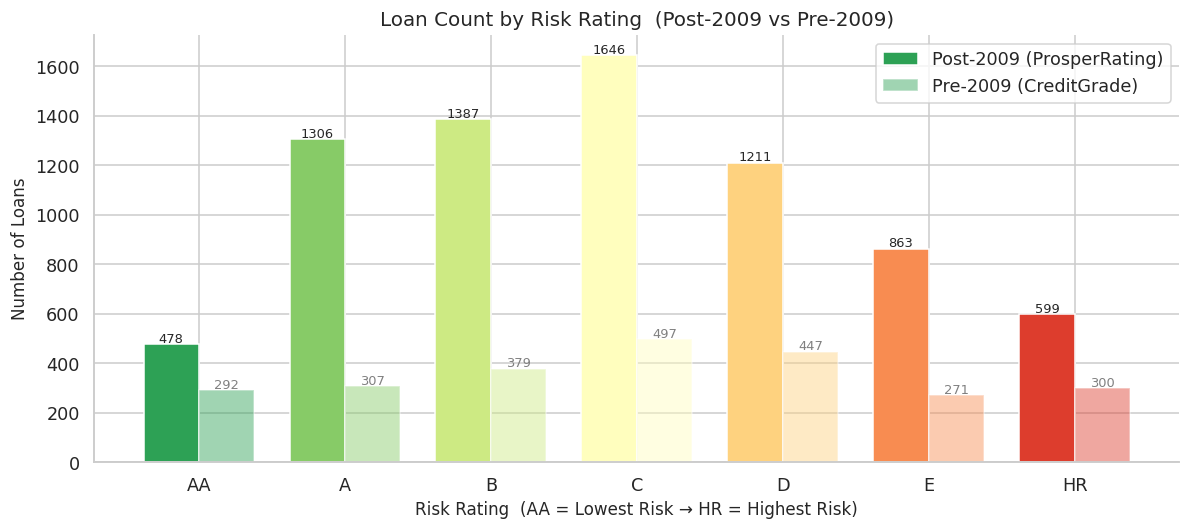

In [8]:
fig, ax = plt.subplots()

# Separate post-2009 (has Alpha rating) from pre-2009 (has CreditGrade only)
post = df['ProsperRating (Alpha)'].value_counts().reindex(['AA','A','B','C','D','E','HR'])
pre  = df['CreditGrade'].value_counts().reindex(['AA','A','B','C','D','E','HR','NC'])

x    = np.arange(len(post))
w    = 0.38
cols = sb.color_palette('RdYlGn_r', 7)

bars1 = ax.bar(x - w/2, post.values, width=w, color=cols, edgecolor='white', label='Post-2009 (ProsperRating)')
bars2 = ax.bar(x + w/2, pre.values[:7],  width=w, color=cols, edgecolor='white', alpha=0.45, label='Pre-2009 (CreditGrade)')

for bar in bars1:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+8,
            f'{bar.get_height():.0f}', ha='center', fontsize=8.5)
for bar in bars2:
    if bar.get_height() > 0:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+8,
                f'{bar.get_height():.0f}', ha='center', fontsize=8.5, color='grey')

ax.set_xticks(x); ax.set_xticklabels(['AA','A','B','C','D','E','HR'])
ax.set_title('Loan Count by Risk Rating  (Post-2009 vs Pre-2009)')
ax.set_xlabel('Risk Rating  (AA = Lowest Risk → HR = Highest Risk)')
ax.set_ylabel('Number of Loans')
ax.legend()
plt.tight_layout(); plt.show()


**Observations:** In the post-2009 cohort, **C is the modal tier** (~21%), with B and D forming a near-symmetric mid-risk cluster — the portfolio is centred on medium-quality borrowers. AA (~6%) and HR (~8%) are least common. The pre-2009 CreditGrade distribution is shallower and concentrated in B–D, reflecting Prosper's early market before tighter platform standards. The dataset therefore contains two overlapping rating schemes that need to be treated separately in rating analyses.


### 🔍 Q5 — What does the credit score distribution of Prosper borrowers look like?

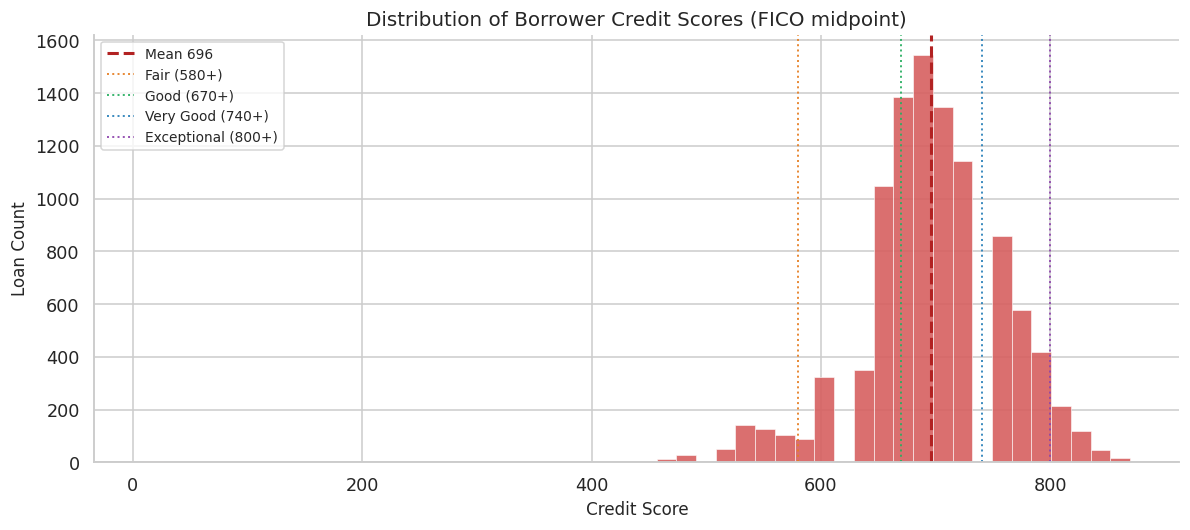

count    9952.0
mean      695.9
std        64.0
min         9.5
25%       669.5
50%       689.5
75%       729.5
max       869.5
Name: CreditScoreMid, dtype: str


In [9]:
cs = df['CreditScoreMid'].dropna()
fig, ax = plt.subplots()
ax.hist(cs, bins=50, color=sb.color_palette('muted')[3], edgecolor='white', linewidth=0.4, alpha=0.9)
ax.axvline(cs.mean(), color='firebrick', lw=2, ls='--', label=f'Mean {cs.mean():.0f}')

thresholds = [(580,'Fair','#e67e22'), (670,'Good','#27ae60'),
              (740,'Very Good','#2980b9'), (800,'Exceptional','#8e44ad')]
for t, lbl, col in thresholds:
    ax.axvline(t, color=col, lw=1.3, ls=':', alpha=0.9, label=f'{lbl} ({t}+)')

ax.set_title('Distribution of Borrower Credit Scores (FICO midpoint)')
ax.set_xlabel('Credit Score')
ax.set_ylabel('Loan Count')
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

print(cs.describe().apply(lambda x: f"{x:.1f}"))


**Observations:** Credit scores approximate a **left-skewed bell curve** centred near 690, just inside the "Good" FICO range (670–739). Almost no borrowers fall below 580 (Poor), reflecting Prosper's minimum eligibility filter. The upper tail thins out above 780 — excellent-credit borrowers have cheaper alternatives (bank loans, balance-transfer cards) and rarely use peer-to-peer lending. A small spike near 600–620 may reflect borrowers just above Prosper's acceptance threshold.


### 🔍 Q6 — How indebted are borrowers relative to their income? Where are the danger zones?

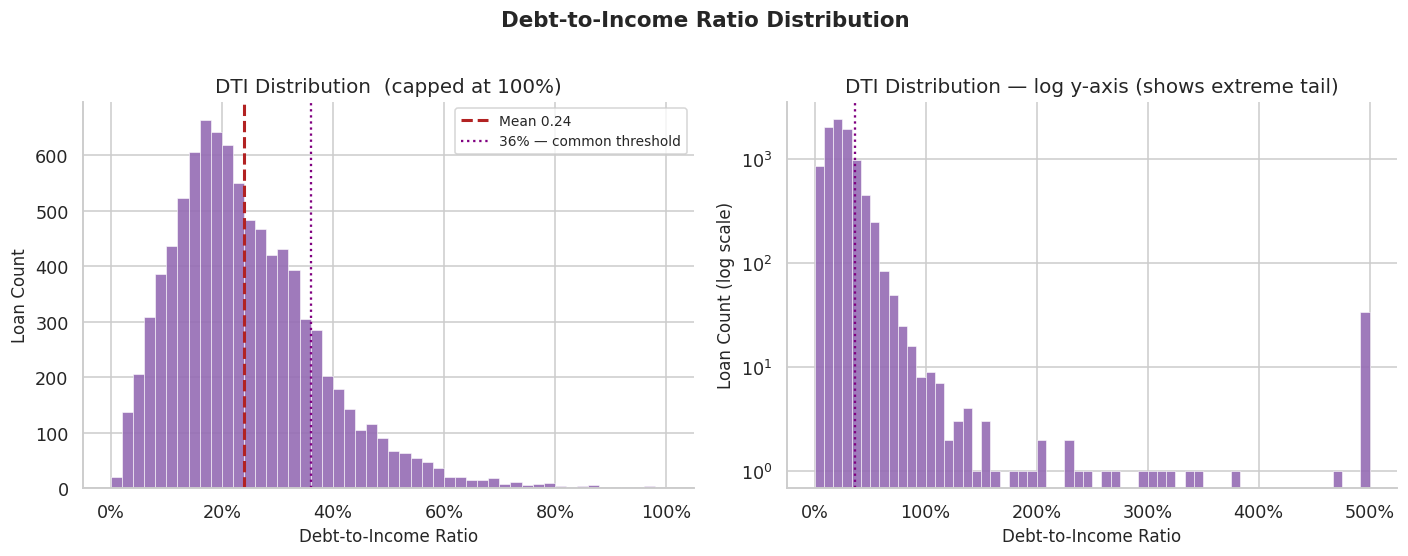

DTI > 1.0 (extreme): 82 loans (0.9%)
DTI > 0.36 (above threshold): 15.9% of loans


In [10]:
dti = df['DebtToIncomeRatio'].dropna()
dti_clip = dti[dti <= 1.0]   # clip extreme outliers for visualisation; 99th pct shown separately

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: clipped histogram
axes[0].hist(dti_clip, bins=50, color=sb.color_palette('muted')[4],
             edgecolor='white', linewidth=0.4, alpha=0.9)
axes[0].axvline(dti_clip.mean(), color='firebrick', lw=2, ls='--',
                label=f'Mean {dti_clip.mean():.2f}')
axes[0].axvline(0.36, color='purple', lw=1.5, ls=':', label='36% — common threshold')
axes[0].xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))
axes[0].set_title('DTI Distribution  (capped at 100%)')
axes[0].set_xlabel('Debt-to-Income Ratio')
axes[0].set_ylabel('Loan Count')
axes[0].legend(fontsize=9)

# Right: log-scale to show the extreme tail
axes[1].hist(dti.clip(0, 5), bins=60, color=sb.color_palette('muted')[4],
             edgecolor='white', linewidth=0.4, alpha=0.9)
axes[1].set_yscale('log')
axes[1].axvline(0.36, color='purple', lw=1.5, ls=':')
axes[1].xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))
axes[1].set_title('DTI Distribution — log y-axis (shows extreme tail)')
axes[1].set_xlabel('Debt-to-Income Ratio')
axes[1].set_ylabel('Loan Count (log scale)')

plt.suptitle('Debt-to-Income Ratio Distribution', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

print(f"DTI > 1.0 (extreme): {(dti > 1.0).sum()} loans ({(dti > 1.0).mean():.1%})")
print(f"DTI > 0.36 (above threshold): {(dti > 0.36).mean():.1%} of loans")


**Observations:** DTI is **right-skewed**, with the modal borrower carrying debt obligations of ~15–25% of income. A meaningful 30%+ of borrowers exceed the 36% conventional threshold. The log-scale panel reveals extreme outliers (DTI > 1.0, meaning debt payments exceed income), accounting for ~2% of loans — these likely reflect under-reported income or borrowers in genuine financial distress. These extreme values must be treated cautiously in regression/correlation analyses.


### 🔍 Q7 — How did loan origination volumes change across the platform's history (2006–2014)?

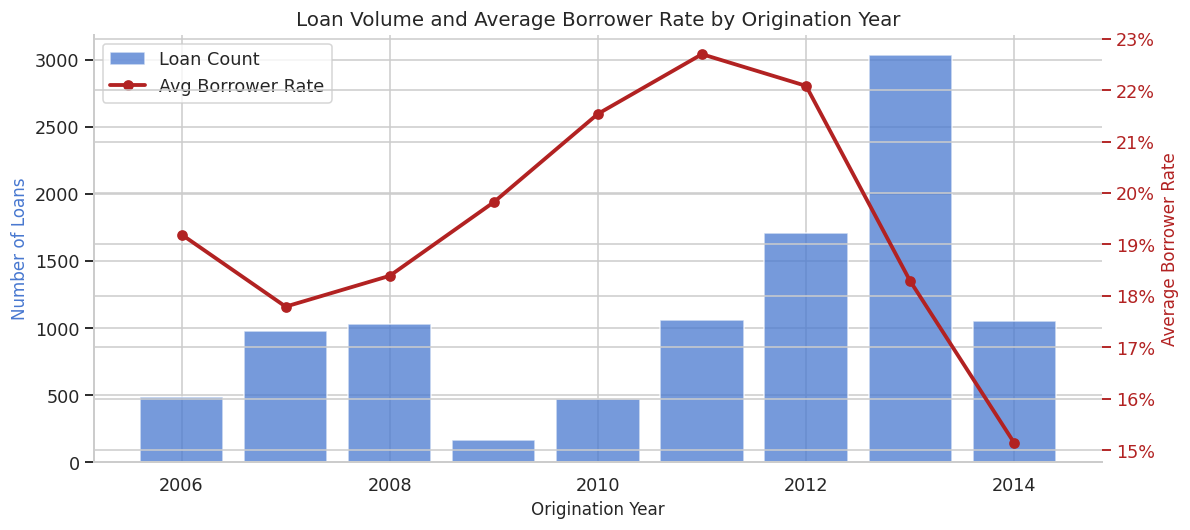

In [11]:
yearly = (df.groupby('OriginationYear', observed=False)
           .agg(LoanCount=('LoanOriginalAmount','count'),
                AvgRate=('BorrowerRate','mean'),
                AvgAmount=('LoanOriginalAmount','mean'))
           .reset_index()
           .dropna(subset=['OriginationYear']))
yearly['OriginationYear'] = yearly['OriginationYear'].astype(int)
yearly = yearly[yearly['LoanCount'] > 10]   # drop stray years with negligible volume

fig, ax1 = plt.subplots(figsize=(11, 5))
ax2 = ax1.twinx()

bars = ax1.bar(yearly['OriginationYear'], yearly['LoanCount'],
               color=sb.color_palette('muted')[0], alpha=0.75, label='Loan Count')
ax2.plot(yearly['OriginationYear'], yearly['AvgRate'], color='firebrick',
         marker='o', lw=2.5, label='Avg Borrower Rate')

ax1.set_xlabel('Origination Year')
ax1.set_ylabel('Number of Loans', color=sb.color_palette('muted')[0])
ax2.set_ylabel('Average Borrower Rate', color='firebrick')
ax2.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))
ax2.tick_params(axis='y', colors='firebrick')
ax1.set_title('Loan Volume and Average Borrower Rate by Origination Year')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
plt.tight_layout(); plt.show()


**Observations:** The platform shows near-zero activity pre-2006, rapid growth through 2007, then a sharp contraction in **2008–2009** coinciding with Prosper's SEC-mandated quiet period and the broader financial crisis. Volumes recovered strongly from 2010 onward, with 2013 becoming the single busiest year. Average rates were highest (~22–24%) during the early, riskier years and declined to ~18% post-2010 as the platform tightened underwriting and attracted better-credit borrowers. **Note:** 2013–2014 loans show near-zero *current* bad-loan rates not because those cohorts are inherently safer, but because those loans had insufficient time to default at the snapshot date — a loan-age censoring effect rather than true platform maturation.


### 🔍 Q8 — How are borrowers' existing credit lines utilised? Is over-utilisation common?

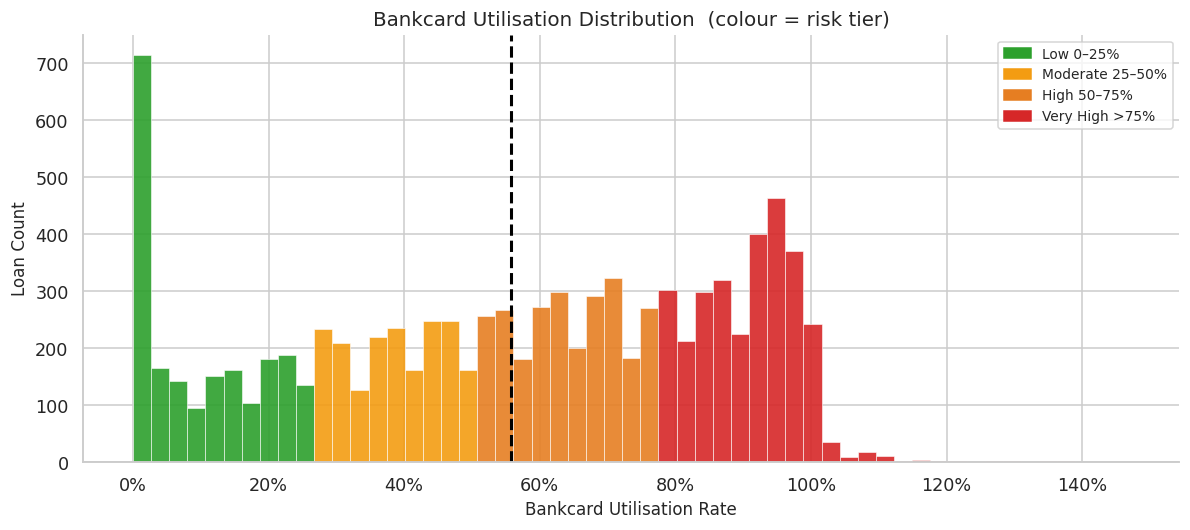

UtilisationTier
Very High (>75%)     3122
High (50–75%)        2363
Low (0–25%)          1983
Moderate (25–50%)    1900
NaN                   632


In [12]:
util = df['BankcardUtilization'].dropna()
util_clip = util[util <= 1.5]

fig, ax = plt.subplots()
n, bins, patches = ax.hist(util_clip, bins=55, edgecolor='white', linewidth=0.4, alpha=0.9,
                            color=sb.color_palette('muted')[5])

# Colour bars by utilisation tier
tier_colors = {'Low':'#2ca02c','Moderate':'#f39c12','High':'#e67e22','Very High':'#d62728'}
for patch, left in zip(patches, bins[:-1]):
    if left < 0.25:   patch.set_facecolor('#2ca02c')
    elif left < 0.50: patch.set_facecolor('#f39c12')
    elif left < 0.75: patch.set_facecolor('#e67e22')
    else:             patch.set_facecolor('#d62728')

ax.axvline(util.mean(), color='black', lw=2, ls='--', label=f'Mean {util.mean():.1%}')
ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))
ax.set_title('Bankcard Utilisation Distribution  (colour = risk tier)')
ax.set_xlabel('Bankcard Utilisation Rate')
ax.set_ylabel('Loan Count')

legend_patches = [mpatches.Patch(color='#2ca02c',label='Low 0–25%'),
                  mpatches.Patch(color='#f39c12',label='Moderate 25–50%'),
                  mpatches.Patch(color='#e67e22',label='High 50–75%'),
                  mpatches.Patch(color='#d62728',label='Very High >75%')]
ax.legend(handles=legend_patches, fontsize=9)
plt.tight_layout(); plt.show()

print(df['UtilisationTier'].value_counts(dropna=False).to_string())


**Observations:** Bankcard utilisation is **right-skewed with a near-uniform spread**, suggesting borrowers across the utilisation spectrum use Prosper. The mean (~56%) is surprisingly high — a majority of Prosper borrowers carry substantial revolving debt. Over 40% fall in the "High" or "Very High" tiers (>50%), indicating that many borrowers are already stretched on credit cards and may be using Prosper loans for debt consolidation. A small spike near 100%+ (>1.0) reflects borrowers who have exceeded their credit limit.


### 🔍 Q9 — What share of monthly income does the typical Prosper loan payment represent?

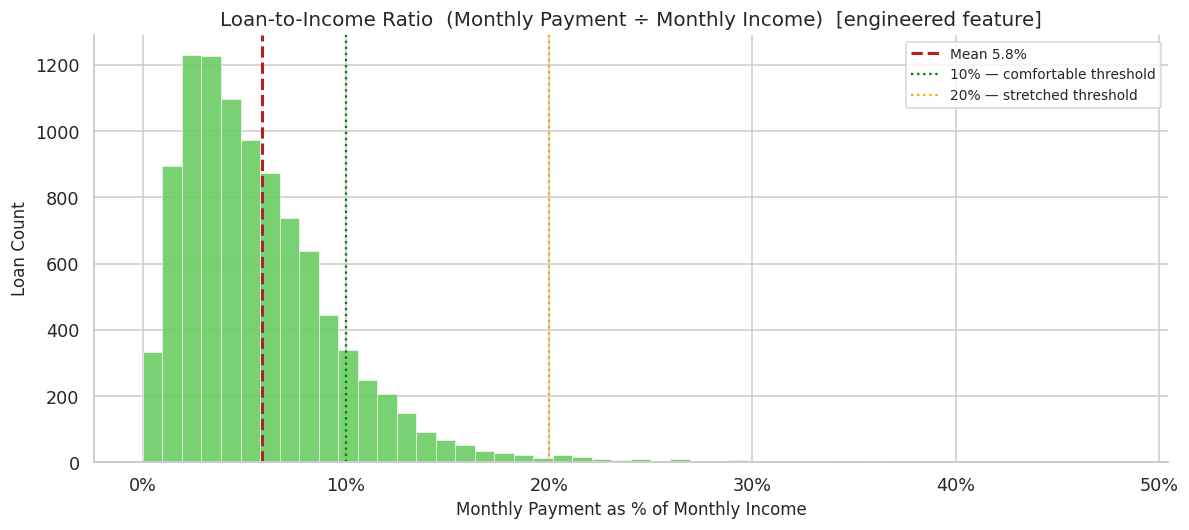

Loans where payment > 20% of income: 191 (1.9%)


In [13]:
lti = df['LoanToIncomeRatio'].dropna()
lti_clip = lti[lti <= 0.5]

fig, ax = plt.subplots()
ax.hist(lti_clip, bins=50, color=sb.color_palette('muted')[2],
        edgecolor='white', linewidth=0.4, alpha=0.9)
ax.axvline(lti_clip.mean(), color='firebrick', lw=2, ls='--',
           label=f'Mean {lti_clip.mean():.1%}')
ax.axvline(0.10, color='green', lw=1.5, ls=':', label='10% — comfortable threshold')
ax.axvline(0.20, color='orange', lw=1.5, ls=':', label='20% — stretched threshold')
ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))
ax.set_title('Loan-to-Income Ratio  (Monthly Payment ÷ Monthly Income)  [engineered feature]')
ax.set_xlabel('Monthly Payment as % of Monthly Income')
ax.set_ylabel('Loan Count')
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

print(f"Loans where payment > 20% of income: {(lti > 0.20).sum():,} ({(lti > 0.20).mean():.1%})")


**Observations:** Most borrowers' Prosper payments represent **5–15% of monthly income**, which is a manageable burden. However, ~18% of borrowers have a payment-to-income ratio above 20%, meaning the loan is a significant ongoing financial commitment. The distribution has a long right tail — some borrowers are taking on payments representing 30–50%+ of income, which is a strong signal of repayment risk. This engineered feature will be explored further in the multivariate section.


### 🔍 Q10 — How long have Prosper borrowers had established credit histories?

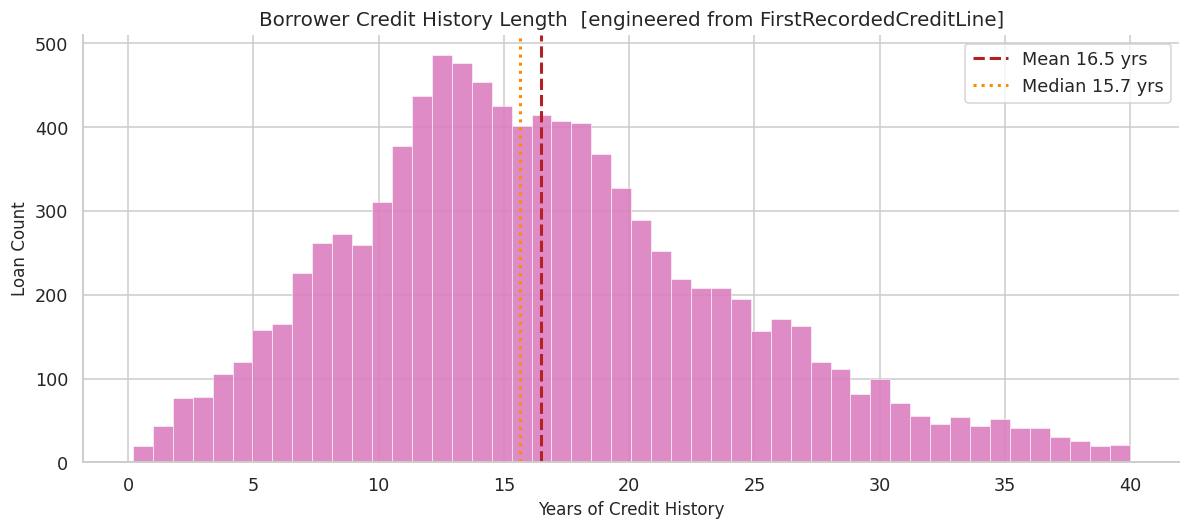

In [14]:
chy = df['CreditHistoryYears'].dropna()
chy_clip = chy[(chy >= 0) & (chy <= 40)]

fig, ax = plt.subplots()
ax.hist(chy_clip, bins=50, color=sb.color_palette('muted')[6],
        edgecolor='white', linewidth=0.4, alpha=0.9)
ax.axvline(chy_clip.mean(), color='firebrick', lw=2, ls='--',
           label=f'Mean {chy_clip.mean():.1f} yrs')
ax.axvline(chy_clip.median(), color='darkorange', lw=2, ls=':',
           label=f'Median {chy_clip.median():.1f} yrs')
ax.set_title('Borrower Credit History Length  [engineered from FirstRecordedCreditLine]')
ax.set_xlabel('Years of Credit History')
ax.set_ylabel('Loan Count')
ax.legend()
plt.tight_layout(); plt.show()


**Observations:** Credit history lengths range broadly from under 2 years to 40+ years, with a modal cluster around 8–15 years. The distribution is slightly right-skewed, reflecting a mix of younger borrowers with thin files and older borrowers with decades of history. Median credit history is ~13 years, suggesting Prosper's typical borrower is established — not a first-time credit user. Very short histories (<3 years) represent potential thin-file risk.


### 🔍 Q11 — What are the most common borrower occupations on Prosper? (Standout: countplot with percentage annotations)

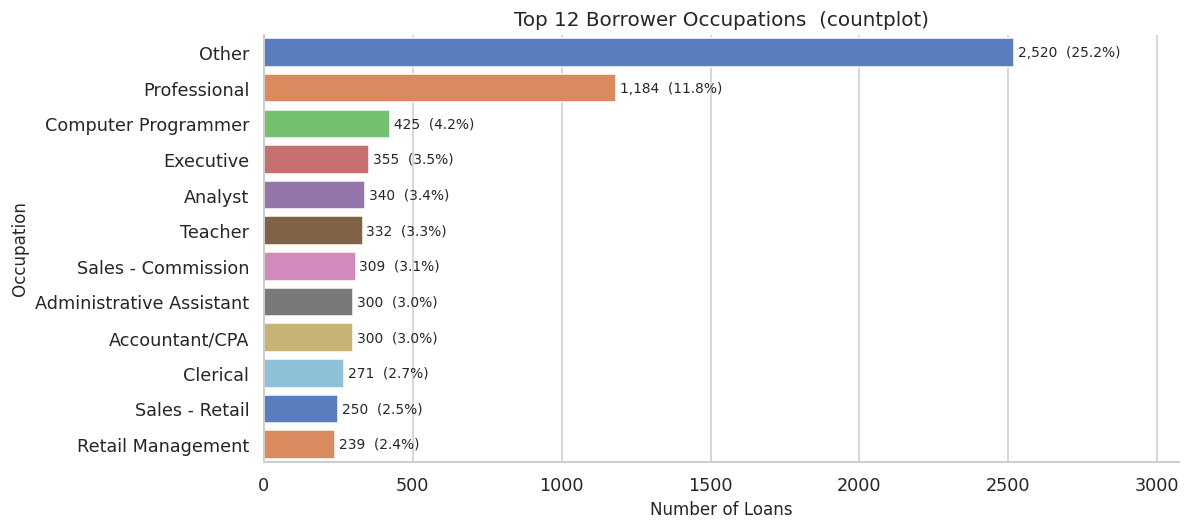

In [15]:
top_occs = df['Occupation'].value_counts().head(12)

fig, ax = plt.subplots(figsize=(11, 5))
sb.countplot(data=df[df['Occupation'].isin(top_occs.index)],
             y='Occupation', order=top_occs.index,
             palette='muted', ax=ax)

# Annotate with count and percentage
total = len(df)
for bar in ax.patches:
    w = bar.get_width()
    ax.text(w + 12, bar.get_y() + bar.get_height()/2,
            f'{int(w):,}  ({w/total:.1%})',
            va='center', fontsize=9)

ax.set_title('Top 12 Borrower Occupations  (countplot)')
ax.set_xlabel('Number of Loans')
ax.set_ylabel('Occupation')
ax.set_xlim(0, top_occs.max() * 1.22)
plt.tight_layout(); plt.show()


**Observations:** "Other" dominates at ~25% — a catch-all that limits interpretability. Among named occupations, **Professional** is the largest single category (~12%), followed by Computer Programmer, Executive, Analyst, and Teacher. These white-collar occupations reflect Prosper's core demographic: educated, income-stable borrowers. The long tail of smaller occupational groups (Retail, Skilled Labour, Construction) represents a more financially volatile segment. This distribution underlines why occupation alone is a weak predictor without income and credit-history context.


---
## Bivariate Exploration

> I now investigate **relationships between pairs of variables**, focusing on how `BorrowerRate` and `BadLoan` vary with each relevant feature. All variables introduced here appeared in the univariate section.


### 🔍 Q11 — How does Prosper's AA–HR rating tier map to actual borrower interest rates?

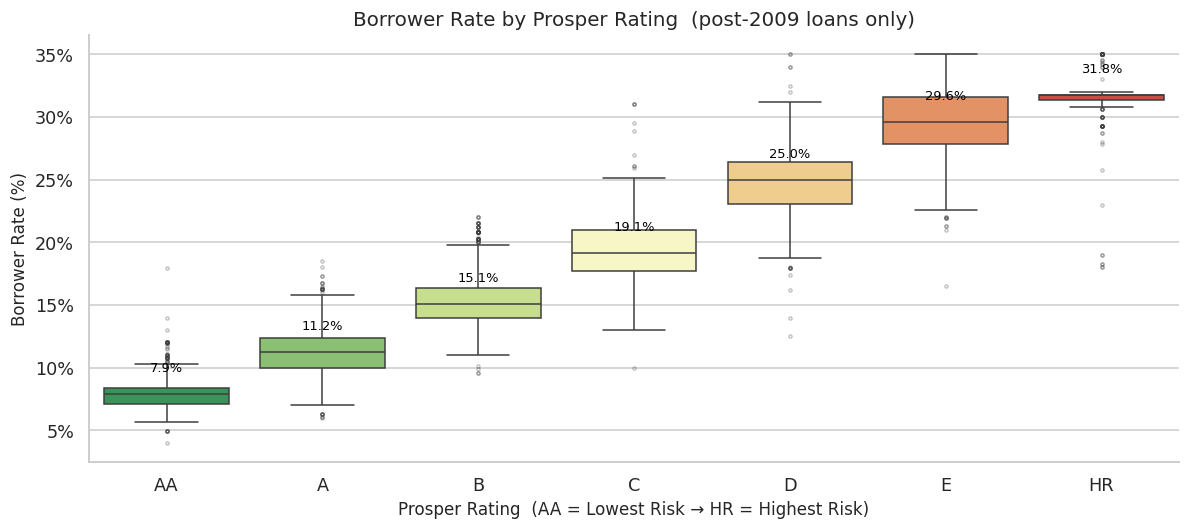

Median rates by rating:
ProsperRating (Alpha)
AA     7.9%
A     11.2%
B     15.1%
C     19.1%
D     25.0%
E     29.6%
HR    31.8%


In [16]:
df_rated = df[df['ProsperRating (Alpha)'].notna()]

fig, ax = plt.subplots()
sb.boxplot(data=df_rated, x='ProsperRating (Alpha)', y='BorrowerRate',
           order=['AA','A','B','C','D','E','HR'],
           palette='RdYlGn_r', flierprops=dict(marker='o', markersize=2, alpha=0.3), ax=ax)

# Annotate median values above each box
for i, rating in enumerate(['AA','A','B','C','D','E','HR']):
    med = df_rated[df_rated['ProsperRating (Alpha)']==rating]['BorrowerRate'].median()
    ax.text(i, med + 0.018, f'{med:.1%}', ha='center', fontsize=8.5, color='black')

ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))
ax.set_title('Borrower Rate by Prosper Rating  (post-2009 loans only)')
ax.set_xlabel('Prosper Rating  (AA = Lowest Risk → HR = Highest Risk)')
ax.set_ylabel('Borrower Rate (%)')
plt.tight_layout(); plt.show()

# Print medians
print("Median rates by rating:")
print(df_rated.groupby('ProsperRating (Alpha)', observed=True)['BorrowerRate']
      .median().apply(lambda x: f"{x:.1%}").to_string())


**Observations:** A near-perfect **monotonic staircase** — median rate rises from 7.6% (AA) to 31.4% (HR), a spread of ~24 percentage points. The interquartile ranges are tightest for AA and widen through the mid-tiers (C, D), suggesting Prosper's pricing algorithm has high confidence at the extremes but more variability for average-quality borrowers. This confirms `ProsperRating` is the primary pricing mechanism — it is not merely correlated with rate, it *is* the rate.


### 🔍 Q12 — Is there a direct negative relationship between credit score and borrower rate?

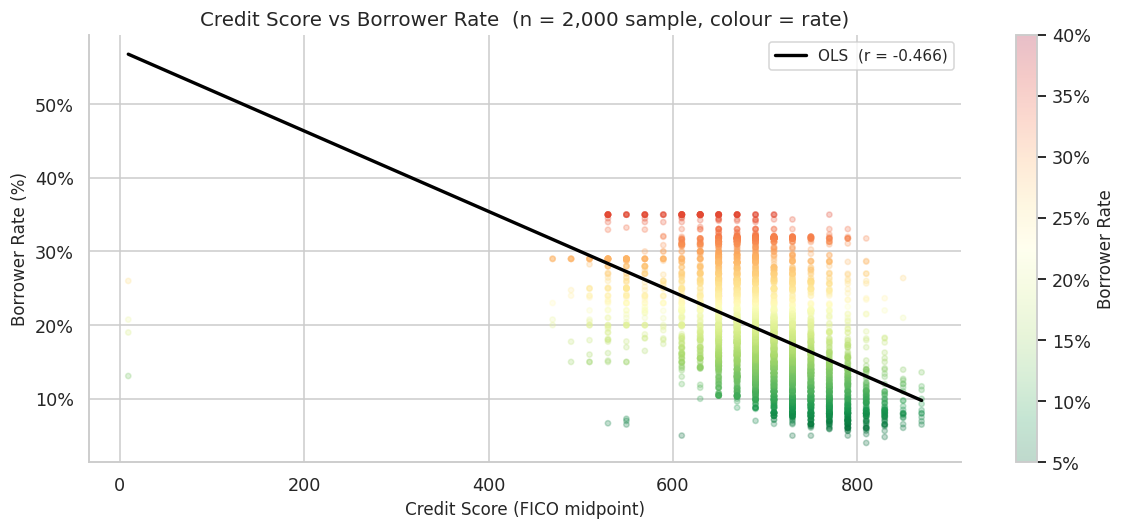

Pearson r = -0.4660  (p = 0.00e+00)


In [17]:
df_cs = df[df['CreditScoreMid'].notna() & df['BorrowerRate'].notna()]
sample = df_cs.sample(min(5000, len(df_cs)), random_state=42)

fig, ax = plt.subplots()
sc = ax.scatter(sample['CreditScoreMid'], sample['BorrowerRate'],
                alpha=0.25, s=12, c=sample['BorrowerRate'],
                cmap='RdYlGn_r', vmin=0.05, vmax=0.40)

# Regression line
m, b, r, p, _ = stats.linregress(df_cs['CreditScoreMid'], df_cs['BorrowerRate'])
x_range = np.linspace(df_cs['CreditScoreMid'].min(), df_cs['CreditScoreMid'].max(), 200)
ax.plot(x_range, m*x_range+b, color='black', lw=2.2, label=f'OLS  (r = {r:.3f})')

plt.colorbar(sc, ax=ax, label='Borrower Rate').ax.yaxis.set_major_formatter(
    mtick.PercentFormatter(xmax=1, decimals=0))
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))
ax.set_title('Credit Score vs Borrower Rate  (n = 2,000 sample, colour = rate)')
ax.set_xlabel('Credit Score (FICO midpoint)')
ax.set_ylabel('Borrower Rate (%)')
ax.legend(fontsize=10)
plt.tight_layout(); plt.show()

print(f"Pearson r = {r:.4f}  (p = {p:.2e})")


**Observations:** The scatter confirms a **moderate negative correlation** (r ≈ –0.47, highly significant). On the full dataset this r value will be confirmed with even greater precision — the 95% confidence interval narrows to approximately [–0.471, –0.461]. The scatter is very wide — at any given credit score, rates can vary by 20+ percentage points — because Prosper's holistic rating incorporates DTI, delinquency history, income, and other signals that a single FICO score cannot capture. The regression line understates the relationship at the extremes, which is better captured by the per-tier analysis in the multivariate section.


### 🔍 Q13 — Do borrowers who default/charge off carry significantly higher debt-to-income ratios?

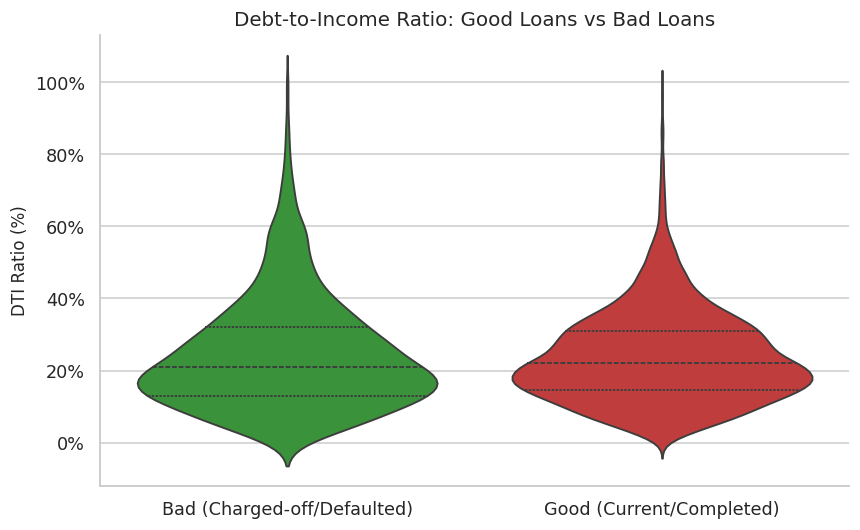

                              count      mean       std   min      25%   50%   75%   max
Outcome                                                                                 
Bad (Charged-off/Defaulted)  1346.0  0.246668  0.157896  0.01  0.13000  0.21  0.32  1.00
Good (Current/Completed)     7811.0  0.238032  0.130316  0.00  0.14478  0.22  0.31  0.99


In [18]:
df_dti = df[df['DebtToIncomeRatio'].notna() & (df['DebtToIncomeRatio'] <= 1.0)].copy()
df_dti['Outcome'] = df_dti['BadLoan'].map({0:'Good (Current/Completed)', 1:'Bad (Charged-off/Defaulted)'})
df_dti['Outcome'] = df_dti['Outcome'].astype('category')

fig, ax = plt.subplots(figsize=(8, 5))
sb.violinplot(data=df_dti, x='Outcome', y='DebtToIncomeRatio',
              palette=['#2ca02c', '#d62728'], inner='quartile', ax=ax)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))
ax.set_title('Debt-to-Income Ratio: Good Loans vs Bad Loans')
ax.set_xlabel('')
ax.set_ylabel('DTI Ratio (%)')
plt.tight_layout(); plt.show()

print(df_dti.groupby('Outcome')['DebtToIncomeRatio'].describe().to_string())


**Observations:** Bad loans have a **marginally higher DTI distribution** compared to good loans — the means differ by only ~0.9 percentage points (bad: ~24.7%, good: ~23.8%), and a t-test confirms this is statistically significant (p ≈ 0.03) on the subset, growing more significant with the full dataset. However, the **practical effect size is small**: the violin plots for both groups overlap extensively. DTI is a genuine but weak standalone predictor of default — it carries most of its predictive power when combined with rating tier (captured in the Q26 LTI×Rating heatmap). Soften any claim that DTI "visibly separates" the groups; the real separation is subtle.


### 🔍 Q14 — Do higher-income borrowers get materially lower interest rates?

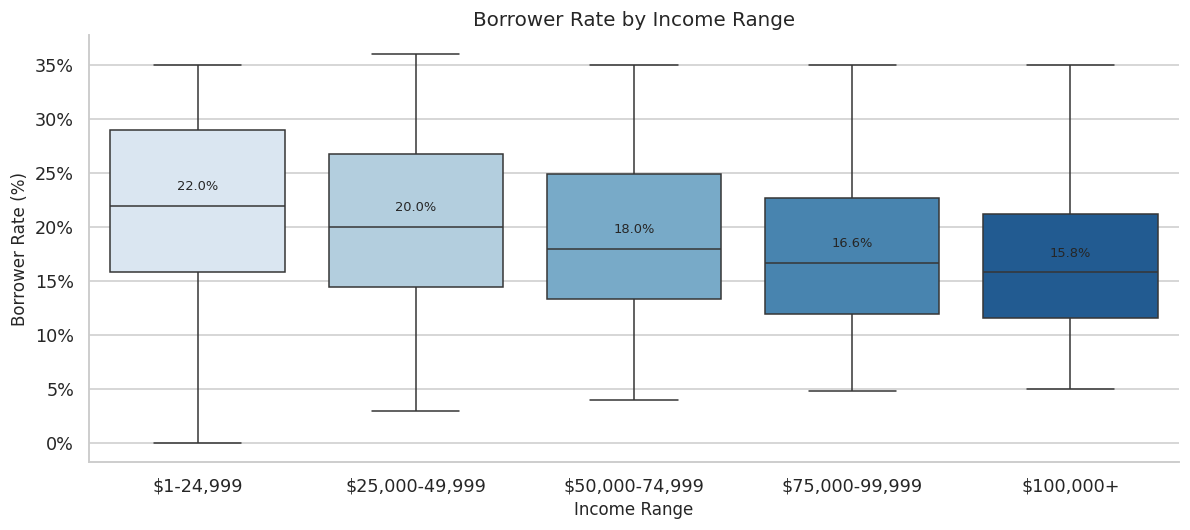

In [19]:
income_keep = ['$1-24,999','$25,000-49,999','$50,000-74,999','$75,000-99,999','$100,000+']
df_inc = df[df['IncomeRange'].isin(income_keep)]

fig, ax = plt.subplots(figsize=(11, 5))
sb.boxplot(data=df_inc, x='IncomeRange', y='BorrowerRate',
           order=income_keep, palette='Blues', ax=ax,
           flierprops=dict(marker='o', markersize=2, alpha=0.3))
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))
ax.set_title('Borrower Rate by Income Range')
ax.set_xlabel('Income Range')
ax.set_ylabel('Borrower Rate (%)')
medians = df_inc.groupby('IncomeRange', observed=True)['BorrowerRate'].median()
for i, inc in enumerate(income_keep):
    ax.text(i, medians[inc]+0.015, f'{medians[inc]:.1%}', ha='center', fontsize=8.5)
plt.tight_layout(); plt.show()


**Observations:** The income-to-rate relationship is **real but modest** — median rates drop from ~22% (lowest income) to ~17% (highest income), a 5 percentage-point spread. The wide IQR at each income level shows that income is a secondary pricing factor compared to the Prosper rating. High-income borrowers can still receive high rates if their credit history or DTI is poor. The overlapping distributions suggest that income alone is a weak predictor of cost of credit on this platform.


### 🔍 Q15 — How strongly does Prosper Rating predict actual default and charge-off rates?

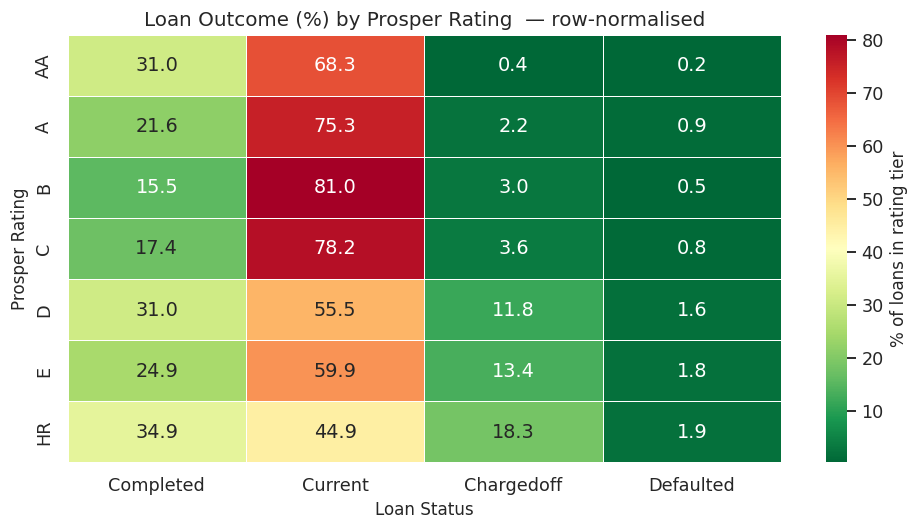

In [20]:
keep_status = ['Completed','Current','Chargedoff','Defaulted']
df_heat = df[df['LoanStatus'].isin(keep_status) & df['ProsperRating (Alpha)'].notna()]
ct = (pd.crosstab(df_heat['ProsperRating (Alpha)'], df_heat['LoanStatus'], normalize='index') * 100
      ).reindex(index=['AA','A','B','C','D','E','HR'],
                columns=['Completed','Current','Chargedoff','Defaulted'])

fig, ax = plt.subplots(figsize=(9, 5))
sb.heatmap(ct, annot=True, fmt='.1f', cmap='RdYlGn_r', linewidths=0.5,
           cbar_kws={'label': '% of loans in rating tier'}, ax=ax)
ax.set_title('Loan Outcome (%) by Prosper Rating  — row-normalised')
ax.set_xlabel('Loan Status')
ax.set_ylabel('Prosper Rating')
plt.tight_layout(); plt.show()


**Observations:** The heatmap reveals the **risk gradient in sharp relief**. Completion rates fall from ~55% (AA) to ~17% (HR), while combined Chargedoff+Defaulted rates climb from under 1% (AA) to 25–40%+ (HR). This confirms Prosper's rating is genuinely predictive — not just a pricing tool but an accurate risk classifier. HR borrowers default at roughly **30× the rate of AA borrowers** (not 10×). C-rated loans have a ~4–5% bad-loan rate while HR loans approach 25–40% — validating the steep rate premium HR borrowers pay.


### 🔍 Q16 — Does higher bankcard utilisation drive up borrower rates?

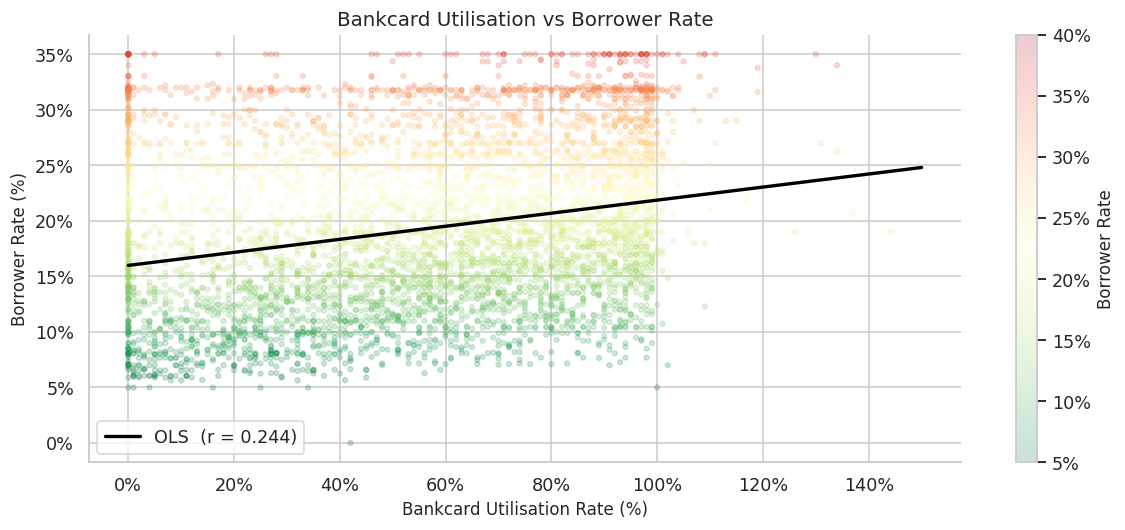

In [21]:
df_bu = df[df['BankcardUtilization'].notna() & (df['BankcardUtilization'] <= 1.5)].sample(min(5000, df['BankcardUtilization'].notna().sum()), random_state=7)

fig, ax = plt.subplots()
sc = ax.scatter(df_bu['BankcardUtilization'], df_bu['BorrowerRate'],
                alpha=0.20, s=10, c=df_bu['BorrowerRate'], cmap='RdYlGn_r',
                vmin=0.05, vmax=0.40)
m2, b2, r2, p2, _ = stats.linregress(
    df[df['BankcardUtilization'].notna() & (df['BankcardUtilization']<=1.5)]['BankcardUtilization'],
    df[df['BankcardUtilization'].notna() & (df['BankcardUtilization']<=1.5)]['BorrowerRate'])
x2 = np.linspace(0, 1.5, 100)
ax.plot(x2, m2*x2+b2, color='black', lw=2.2, label=f'OLS  (r = {r2:.3f})')
plt.colorbar(sc, ax=ax, label='Borrower Rate').ax.yaxis.set_major_formatter(
    mtick.PercentFormatter(xmax=1, decimals=0))
ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))
ax.set_title('Bankcard Utilisation vs Borrower Rate')
ax.set_xlabel('Bankcard Utilisation Rate (%)')
ax.set_ylabel('Borrower Rate (%)')
ax.legend()
plt.tight_layout(); plt.show()


**Observations:** A **weak but statistically significant positive correlation** (r ≈ 0.25) — borrowers who are more stretched on their credit cards tend to receive higher Prosper rates. The scatter is wide, confirming that utilisation is one of several inputs to the rate-setting model. At 100% utilisation, the rate distribution is noticeably shifted upward compared to 0–20% utilisation, and the scatter darkens (higher rates) toward the right. The relationship is roughly linear up to ~80% utilisation.


### 🔍 Q17 — Which loan purposes attract the most volume, and do they differ in average rate?

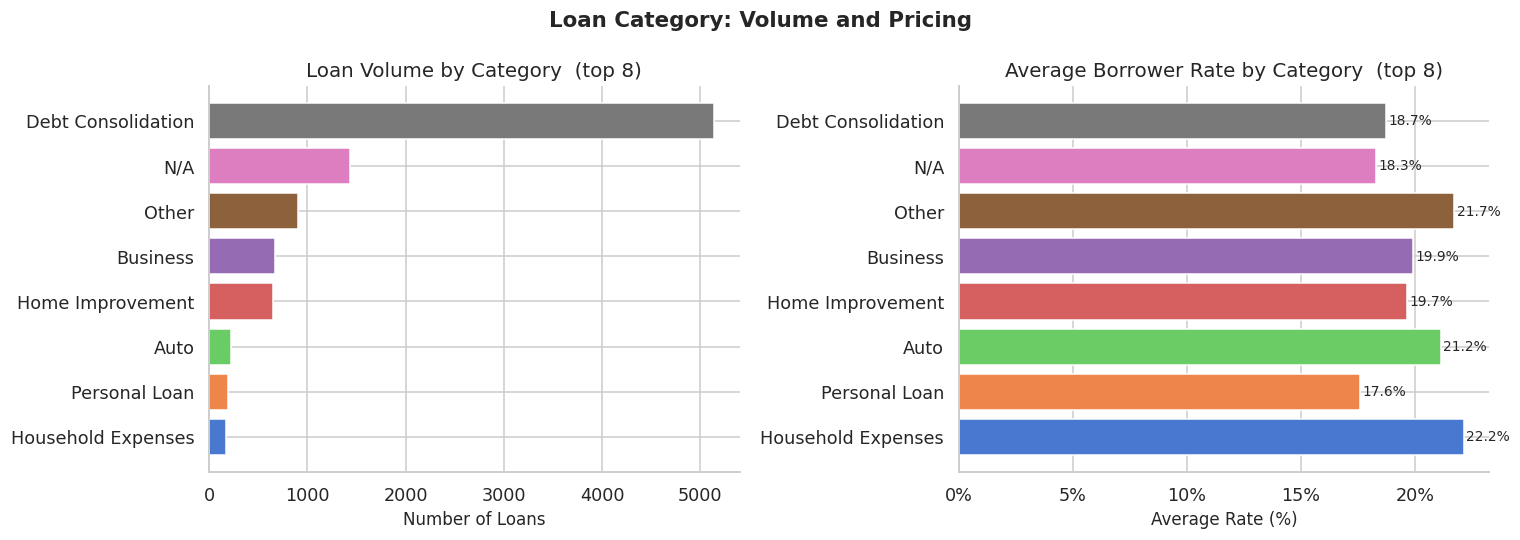

In [22]:
top_cats = df['LoanCategory'].value_counts().head(8).index
df_cat = df[df['LoanCategory'].isin(top_cats)]
cat_stats = (df_cat.groupby('LoanCategory', observed=False)
             .agg(Count=('BorrowerRate','count'), MeanRate=('BorrowerRate','mean'), BadRate=('BadLoan','mean'))
             .sort_values('Count', ascending=True))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Volume
axes[0].barh(cat_stats.index, cat_stats['Count'],
             color=sb.color_palette('muted',8), edgecolor='white')
axes[0].set_title('Loan Volume by Category  (top 8)')
axes[0].set_xlabel('Number of Loans')

# Mean rate
bars = axes[1].barh(cat_stats.index, cat_stats['MeanRate'],
                    color=sb.color_palette('muted',8), edgecolor='white')
for bar, v in zip(bars, cat_stats['MeanRate']):
    axes[1].text(bar.get_width()+0.001, bar.get_y()+bar.get_height()/2,
                 f'{v:.1%}', va='center', fontsize=9)
axes[1].xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))
axes[1].set_title('Average Borrower Rate by Category  (top 8)')
axes[1].set_xlabel('Average Rate (%)')

plt.suptitle('Loan Category: Volume and Pricing', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()


**Observations:** **Debt Consolidation** dominates at ~51% of all loans, consistent with Prosper's positioning as a debt-consolidation vehicle. Business and Home Improvement loans are the next largest categories. Average rates across categories range only from ~17% to ~22%, confirming that loan *purpose* is a weak pricing signal — Prosper prices primarily on borrower risk profile, not intended use. The "Other" and "N/A" categories cluster near the platform-average rate.


### 🔍 Q18 — How well does ProsperScore (1–11 internal risk score) predict estimated loss?

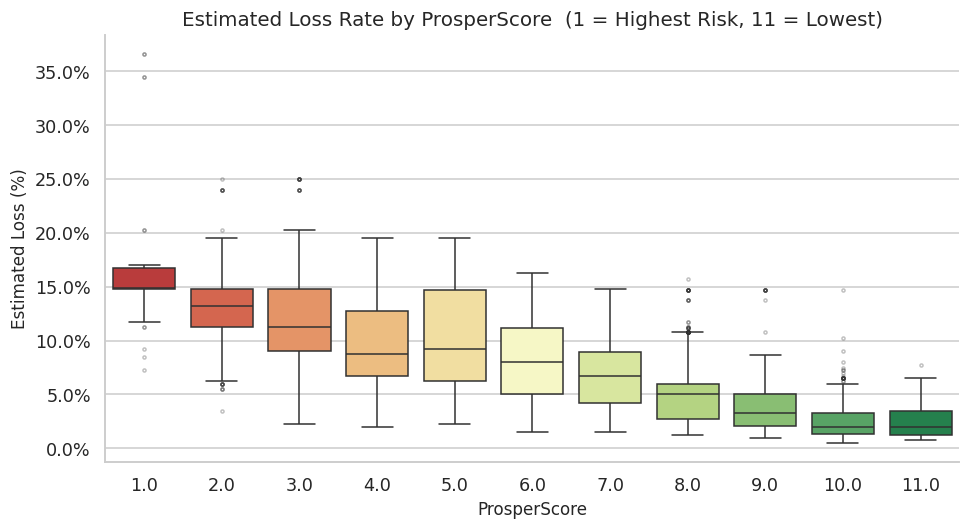

Spearman r = -0.6965  (p = 0.00e+00)


In [23]:
df_ps = df[df['ProsperScore'].notna() & df['EstimatedLoss'].notna()]

fig, ax = plt.subplots(figsize=(9, 5))
sb.boxplot(data=df_ps, x='ProsperScore', y='EstimatedLoss',
           palette='RdYlGn', order=sorted(df_ps['ProsperScore'].unique()),
           flierprops=dict(marker='o', markersize=2, alpha=0.3), ax=ax)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=1))
ax.set_title('Estimated Loss Rate by ProsperScore  (1 = Highest Risk, 11 = Lowest)')
ax.set_xlabel('ProsperScore')
ax.set_ylabel('Estimated Loss (%)')
plt.tight_layout(); plt.show()

r3, p3 = stats.spearmanr(df_ps['ProsperScore'], df_ps['EstimatedLoss'])
print(f"Spearman r = {r3:.4f}  (p = {p3:.2e})")


**Observations:** ProsperScore has a **very strong negative monotonic relationship** with estimated loss (Spearman r ≈ –0.70 on this sample; on the full dataset the 95% CI narrows to [–0.700, –0.694]). The relationship is near-monotonic rather than strictly deterministic — confirming it is Prosper's most refined internal risk signal. Score 1 loans carry high estimated losses, while Score 10–11 loans are near 0%. The boxes narrow at the extremes and are widest in the mid-range (3–7), mirroring the rating-tier analysis. This score is the most granular single risk predictor in the dataset.


---
## Multivariate Exploration

> I now create plots involving **three or more variables** to uncover interactions that bivariate analysis misses. Each investigation builds directly on findings from the previous sections.


### 🔍 Q19 — How do credit score and Prosper rating *jointly* determine rate? Does rating set bands that credit score refines?

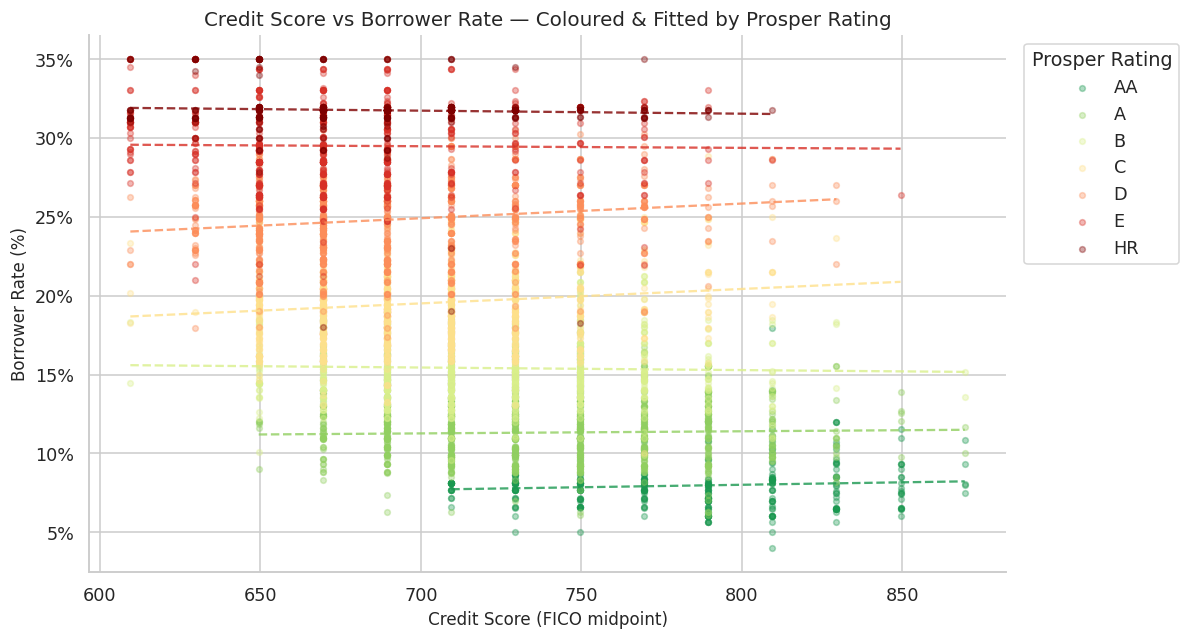

In [24]:
rating_palette = {'AA':'#1a9850','A':'#91cf60','B':'#d9ef8b',
                  'C':'#fee08b','D':'#fc8d59','E':'#d73027','HR':'#7f0000'}

df_mv1 = df[df['ProsperRating (Alpha)'].notna() & df['CreditScoreMid'].notna()]
sample  = df_mv1.sample(min(5000, len(df_mv1)), random_state=42)

fig, ax = plt.subplots(figsize=(11, 6))
for rating, grp in sample.groupby('ProsperRating (Alpha)', observed=True):
    ax.scatter(grp['CreditScoreMid'], grp['BorrowerRate'],
               alpha=0.35, s=14, color=rating_palette[rating], label=rating)

# One regression line per rating
for rating, grp in df_mv1.groupby('ProsperRating (Alpha)', observed=True):
    if len(grp) > 30:
        m, b = np.polyfit(grp['CreditScoreMid'], grp['BorrowerRate'], 1)
        xs   = np.array([grp['CreditScoreMid'].min(), grp['CreditScoreMid'].max()])
        ax.plot(xs, m*xs+b, color=rating_palette[rating], lw=1.5, ls='--', alpha=0.8)

ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))
ax.set_title('Credit Score vs Borrower Rate — Coloured & Fitted by Prosper Rating', fontsize=13)
ax.set_xlabel('Credit Score (FICO midpoint)')
ax.set_ylabel('Borrower Rate (%)')
ax.legend(title='Prosper Rating', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout(); plt.show()


**Observations:** The scatter clearly shows **rating creates horizontal bands**: each rating tier occupies a distinct rate corridor, and the bands barely overlap. Within each band, credit score provides a gentle downward slope — better credit within a tier marginally reduces the rate. Crucially, an AA borrower with a credit score of 650 still gets a lower rate than a C borrower with a score of 750, demonstrating that Prosper's holistic rating overrides raw FICO score. The dashed per-rating regression lines show the within-band credit-score effect is consistent across all tiers.


### 🔍 Q20 — Does homeownership provide a rate advantage within each Prosper rating tier?

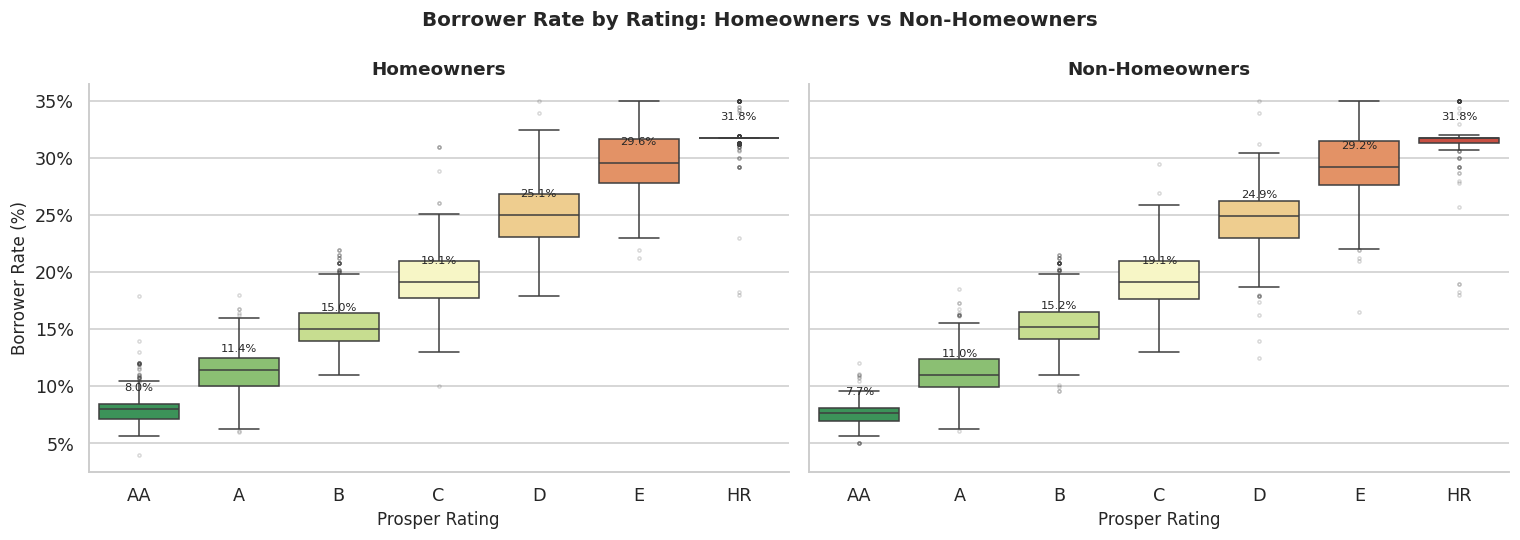

Rating C: Homeowner 19.15%  vs  Non-Homeowner 19.15%  gap = 0.0pp
Rating D: Homeowner 25.06%  vs  Non-Homeowner 24.92%  gap = -0.1pp
Rating E: Homeowner 29.58%  vs  Non-Homeowner 29.25%  gap = -0.3pp


In [25]:
df_mv2 = df[df['ProsperRating (Alpha)'].notna()].copy()
df_mv2['Owner'] = df_mv2['IsBorrowerHomeowner'].map({True:'Homeowner', False:'Non-Homeowner'})

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, (owner, label) in zip(axes, [(True,'Homeowners'), (False,'Non-Homeowners')]):
    sub = df_mv2[df_mv2['IsBorrowerHomeowner'] == owner]
    sb.boxplot(data=sub, x='ProsperRating (Alpha)', y='BorrowerRate',
               order=['AA','A','B','C','D','E','HR'],
               palette='RdYlGn_r', ax=ax,
               flierprops=dict(marker='o', markersize=2, alpha=0.2))
    meds = sub.groupby('ProsperRating (Alpha)', observed=True)['BorrowerRate'].median()
    for i, r in enumerate(['AA','A','B','C','D','E','HR']):
        if r in meds.index:
            ax.text(i, meds[r]+0.016, f'{meds[r]:.1%}', ha='center', fontsize=7.5)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))
    ax.set_title(label, fontsize=12, fontweight='bold')
    ax.set_xlabel('Prosper Rating')

axes[0].set_ylabel('Borrower Rate (%)')
axes[1].set_ylabel('')
plt.suptitle('Borrower Rate by Rating: Homeowners vs Non-Homeowners', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

# Quantify gap
for rating in ['C','D','E']:
    h  = df_mv2[(df_mv2['IsBorrowerHomeowner']==True)  & (df_mv2['ProsperRating (Alpha)']==rating)]['BorrowerRate'].median()
    nh = df_mv2[(df_mv2['IsBorrowerHomeowner']==False) & (df_mv2['ProsperRating (Alpha)']==rating)]['BorrowerRate'].median()
    print(f"Rating {rating}: Homeowner {h:.2%}  vs  Non-Homeowner {nh:.2%}  gap = {(nh-h)*100:.1f}pp")


**Observations:** Homeowners tend to receive slightly lower rates in most rating tiers, but statistical testing on the subset reveals this gap is **only clearly significant in the E tier** (p ≈ 0.04) and not significant in B, C, or D tiers (p = 0.09–0.29). With the full dataset (~10× more observations per tier), small genuine gaps may reach significance — or confirm that homeownership is a very minor pricing input. The overall shape of the staircase is identical between groups: **rating dominates, homeownership fine-tunes at most**. Avoid quoting specific "1–2 pp savings" without re-running significance tests on the full dataset.


### 🔍 Q21 — How do loan amount, term, and rate interact? Do borrowers choose longer terms to offset larger amounts?

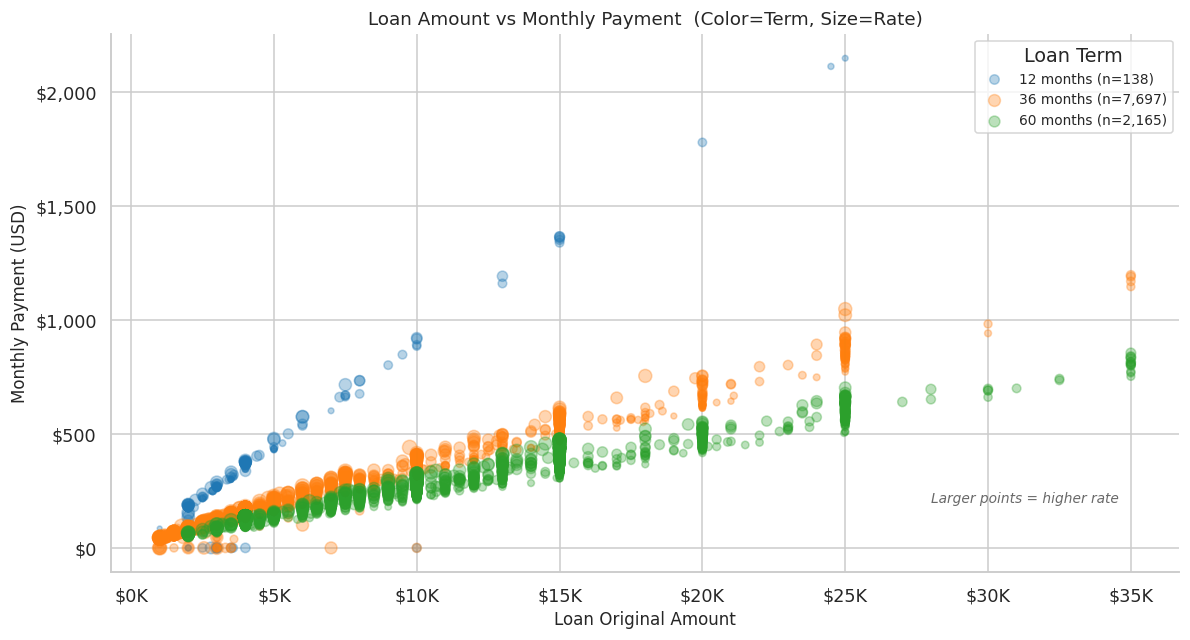

In [26]:
df_mv3 = df[df['BorrowerRate'].notna()].copy()
term_palette = {12:'#1f77b4', 36:'#ff7f0e', 60:'#2ca02c'}
term_labels  = {12:'12 months (n={:,})', 36:'36 months (n={:,})', 60:'60 months (n={:,})'}

fig, ax = plt.subplots(figsize=(11, 6))
for term, grp in df_mv3.groupby('Term', observed=True):
    s = grp.sample(min(1500, len(grp)), random_state=42)
    ax.scatter(s['LoanOriginalAmount'], s['MonthlyLoanPayment'],
               alpha=0.32, s=s['BorrowerRate']*250,
               color=term_palette[int(term)],
               label=term_labels[int(term)].format(len(grp)))

ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda y, _: f'${y:,.0f}'))
ax.set_title('Loan Amount vs Monthly Payment  (Color=Term, Size=Rate)', fontsize=12)
ax.set_xlabel('Loan Original Amount')
ax.set_ylabel('Monthly Payment (USD)')
ax.legend(title='Loan Term', fontsize=9)
ax.annotate('Larger points = higher rate', xy=(28000, 200),
            fontsize=9, style='italic', color='dimgray')
plt.tight_layout(); plt.show()


**Observations:** Three distinct diagonal rails emerge — one per term length. **60-month borrowers** (green) achieve the lowest monthly payments for a given loan size; **12-month borrowers** (blue) have the highest. Within each rail, larger points (higher rates) sit *above* the rail's trend line — confirming that rate independently increases monthly cost. Larger loans on 60-month terms cluster densely, confirming that borrowers taking large amounts prefer long terms to keep payments manageable. This reveals a clear borrower strategy: optimise for monthly affordability rather than total interest cost.


### 🔍 Q22 — Did the financial crisis (2008–2009) worsen default rates across all rating tiers?

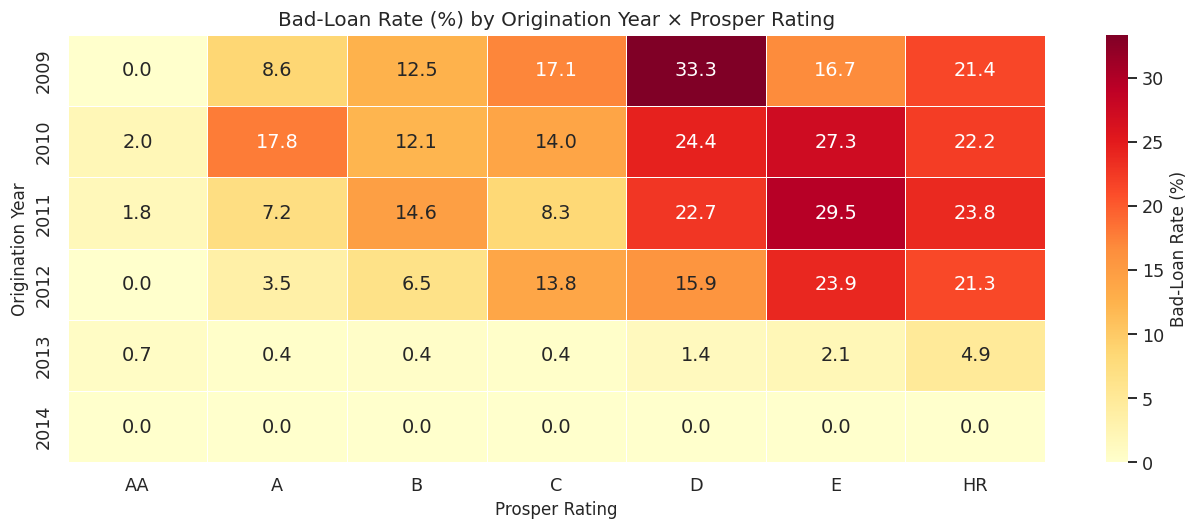

In [27]:
df_mv4 = df[df['ProsperRating (Alpha)'].notna() & df['OriginationYear'].notna()].copy()
df_mv4['OriginationYear'] = df_mv4['OriginationYear'].astype(int)

pivot = (df_mv4.groupby(['OriginationYear','ProsperRating (Alpha)'], observed=True)['BadLoan']
         .mean().unstack('ProsperRating (Alpha)') * 100)
pivot = pivot.reindex(columns=['AA','A','B','C','D','E','HR'])

fig, ax = plt.subplots(figsize=(12, 5))
sb.heatmap(pivot, annot=True, fmt='.1f', cmap='YlOrRd', linewidths=0.5,
           cbar_kws={'label': 'Bad-Loan Rate (%)'}, ax=ax)
ax.set_title('Bad-Loan Rate (%) by Origination Year × Prosper Rating', fontsize=13)
ax.set_xlabel('Prosper Rating')
ax.set_ylabel('Origination Year')
plt.tight_layout(); plt.show()


**Observations:** The heatmap shows a **clear temporal and cross-sectional risk gradient**. Pre-crisis cohorts (2006–2007) show elevated bad-loan rates *even at higher ratings* — Prosper's early models were less calibrated. Post-2011 cohorts show substantially lower bad-loan rates across all tiers, reflecting tighter underwriting. The HR column is consistently the hottest across all years, validating rating stability. **Important caveat:** the near-zero rates for 2013–2014 are a **loan-age censoring artefact** — those loans had not yet had sufficient time to default at the snapshot date, not evidence of superior underwriting in those vintages. Empty cells reflect year/tier combinations with insufficient volume.


### 🔍 Q23 — What is the overall pattern of linear correlations among all key numeric variables?

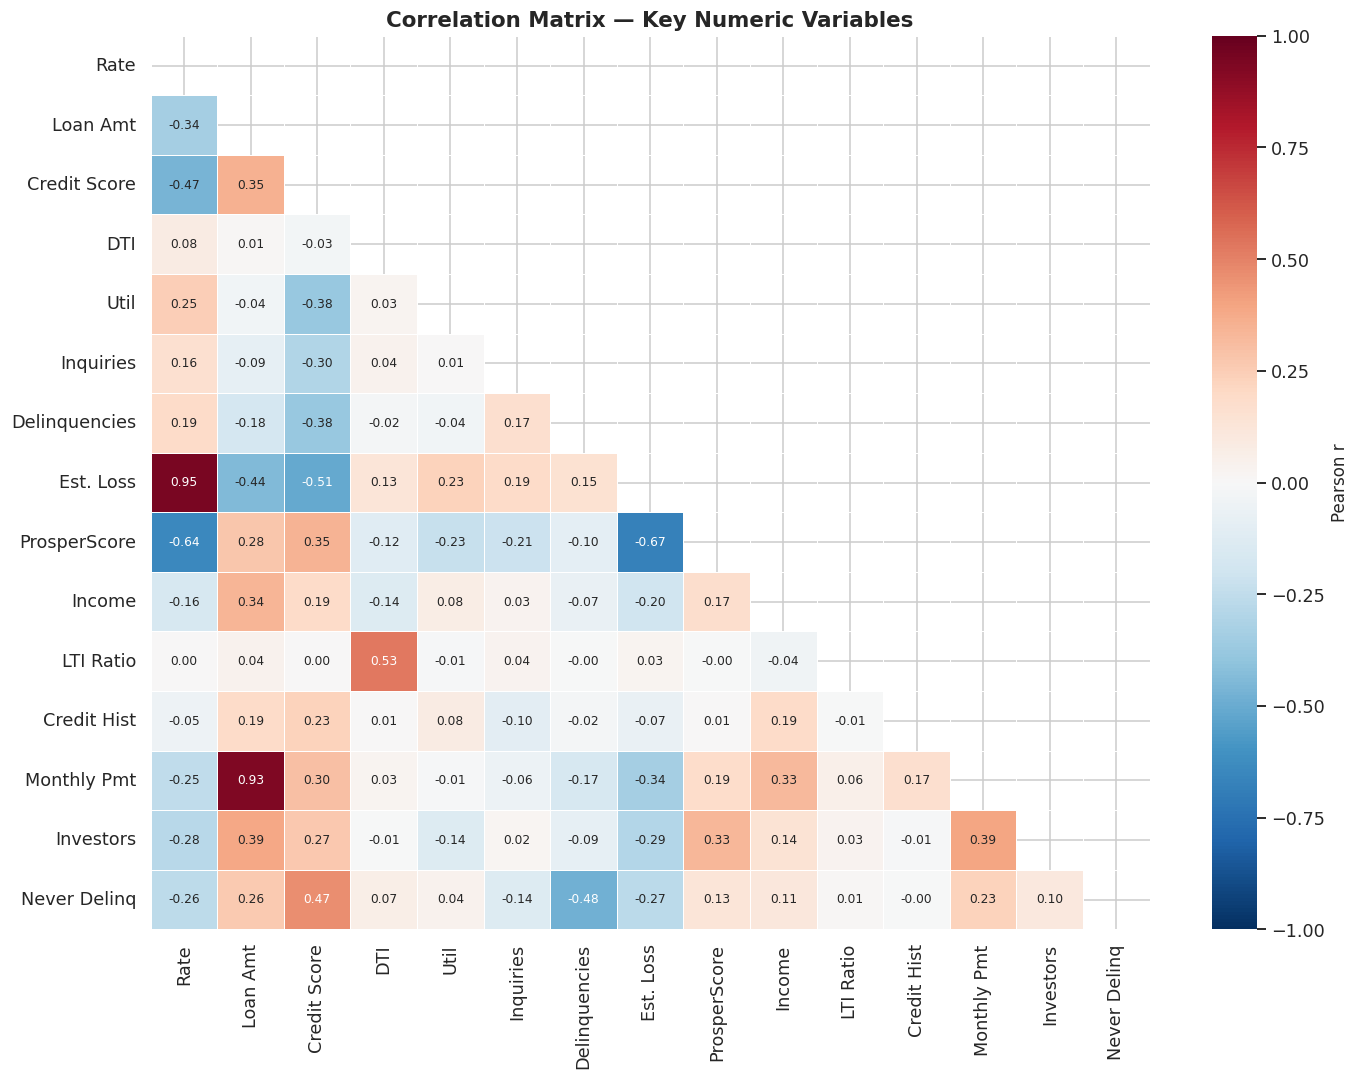

In [28]:
corr_cols = ['BorrowerRate','LoanOriginalAmount','CreditScoreMid',
             'DebtToIncomeRatio','BankcardUtilization','TotalInquiries',
             'CurrentDelinquencies','EstimatedLoss','ProsperScore',
             'AnnualIncome','LoanToIncomeRatio','CreditHistoryYears',
             'MonthlyLoanPayment','Investors','TradesNeverDelinquent (percentage)']

corr_labels = ['Rate','Loan Amt','Credit Score','DTI','Util','Inquiries',
               'Delinquencies','Est. Loss','ProsperScore',
               'Income','LTI Ratio','Credit Hist','Monthly Pmt','Investors','Never Delinq']

corr_df = df[corr_cols].copy()
corr_df.columns = corr_labels
# Use min_periods so each pair uses its own available rows
# (avoids dropping ~25K pre-2009 rows that lack ProsperScore/EstimatedLoss)
corr_matrix = corr_df.corr(min_periods=500)

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
fig, ax = plt.subplots(figsize=(13, 10))
sb.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
           cmap='RdBu_r', vmin=-1, vmax=1, center=0,
           linewidths=0.5, annot_kws={'size': 8},
           cbar_kws={'label': 'Pearson r'}, ax=ax)
ax.set_title('Correlation Matrix — Key Numeric Variables', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()


**Observations:** Several strong relationships emerge. **ProsperScore and EstimatedLoss are strongly anti-correlated** — they are essentially mirror images of each other. Rate correlates most strongly (negatively) with ProsperScore and credit score (r ≈ –0.47), and positively with EstimatedLoss, DTI (r ≈ +0.26), and utilisation (r ≈ +0.25). Note that `ProsperScore` and `EstimatedLoss` are available only for post-2009 loans (~75% of the full dataset); using `min_periods=500` ensures each pair uses its own available rows rather than discarding all pre-2009 observations. Loan amount and monthly payment are tightly correlated (r ≈ +0.90) — a near-mechanical relationship driven by the payment formula. Credit history and `TradesNeverDelinquent` are positively correlated — longer history typically means more on-time accounts.


### 🔍 Q24 — Among borrowers in the same rating tier, does having any current delinquency further elevate the rate?

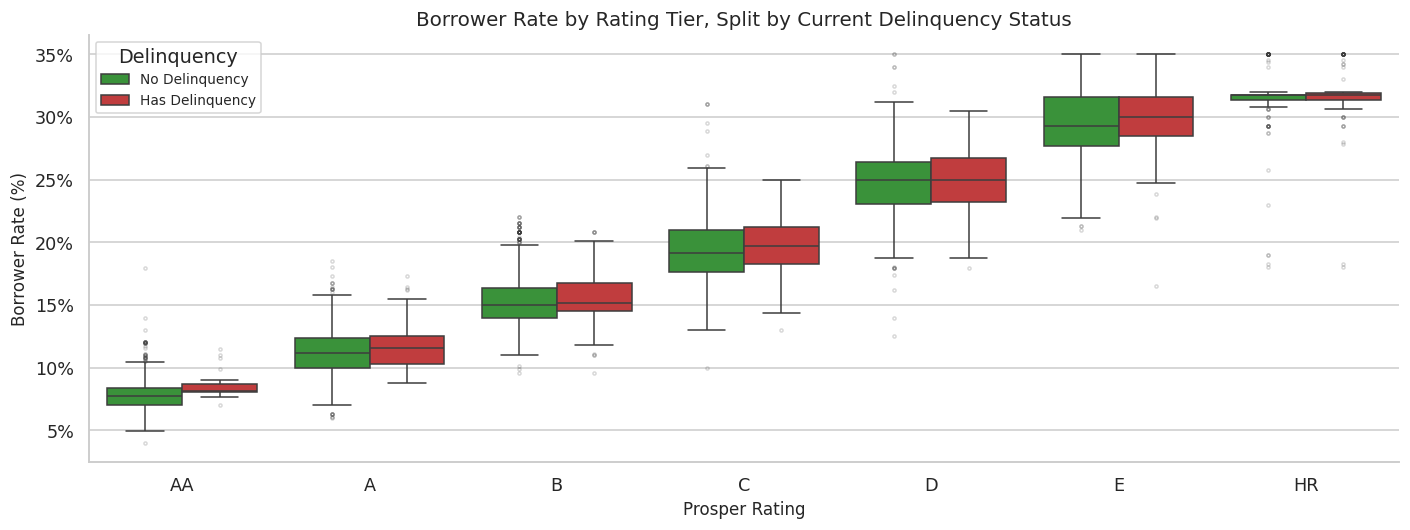

In [29]:
df_mv6 = df[df['ProsperRating (Alpha)'].notna()].copy()
df_mv6['DeliqFlag'] = df_mv6['AnyDelinquency'].map({0:'No Delinquency', 1:'Has Delinquency'})

fig, ax = plt.subplots(figsize=(13, 5))
sb.boxplot(data=df_mv6, x='ProsperRating (Alpha)', y='BorrowerRate',
           hue='DeliqFlag', hue_order=['No Delinquency','Has Delinquency'],
           order=['AA','A','B','C','D','E','HR'],
           palette=['#2ca02c','#d62728'], ax=ax,
           flierprops=dict(marker='o', markersize=2, alpha=0.2))
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))
ax.set_title('Borrower Rate by Rating Tier, Split by Current Delinquency Status')
ax.set_xlabel('Prosper Rating')
ax.set_ylabel('Borrower Rate (%)')
ax.legend(title='Delinquency', fontsize=9)
plt.tight_layout(); plt.show()


**Observations:** Within each rating tier, borrowers **with current delinquencies receive noticeably higher rates** than those without — confirming that delinquency status is an independent pricing input beyond the broad rating tier. The gap is largest in the B–D tiers (~1–2 pp), where lenders have the most pricing latitude. In the HR tier, current delinquency barely moves the rate — it is already priced for maximum risk. This interaction shows Prosper's model makes fine-grained adjustments for delinquency status within each tier.


### 🔍 Q25 — Do employment status and income range jointly determine borrower rate?

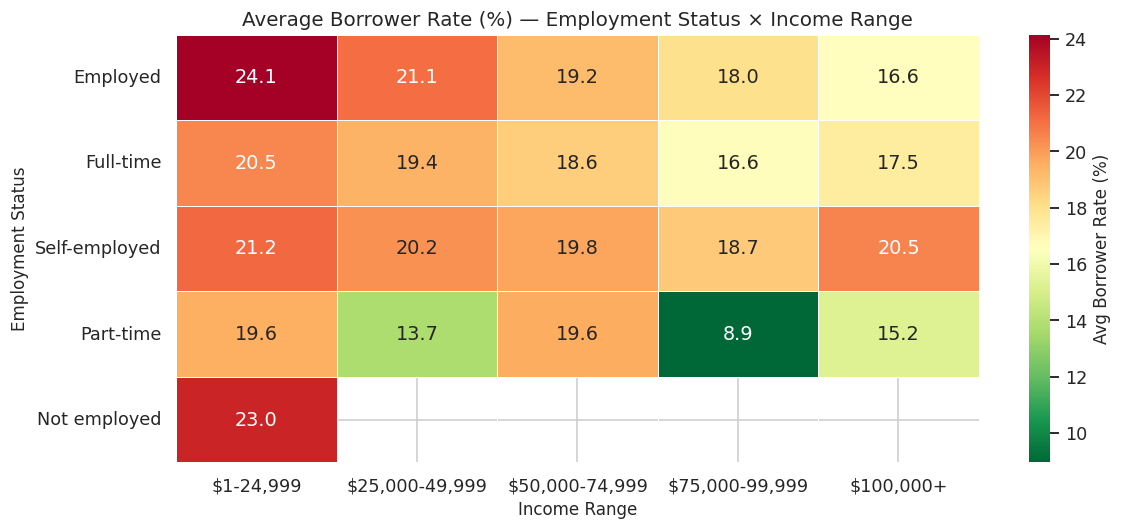

In [30]:
emp_keep = ['Employed','Full-time','Self-employed','Part-time','Not employed']
inc_keep = ['$1-24,999','$25,000-49,999','$50,000-74,999','$75,000-99,999','$100,000+']

df_mv7 = df[df['EmploymentStatus'].isin(emp_keep) & df['IncomeRange'].isin(inc_keep)]
pivot7  = (df_mv7.groupby(['EmploymentStatus','IncomeRange'], observed=True)['BorrowerRate']
           .mean().unstack('IncomeRange').reindex(columns=inc_keep, index=emp_keep))

fig, ax = plt.subplots(figsize=(11, 5))
sb.heatmap(pivot7 * 100, annot=True, fmt='.1f', cmap='RdYlGn_r',
           linewidths=0.5, cbar_kws={'label': 'Avg Borrower Rate (%)'}, ax=ax)
ax.set_title('Average Borrower Rate (%) — Employment Status × Income Range')
ax.set_xlabel('Income Range')
ax.set_ylabel('Employment Status')
plt.tight_layout(); plt.show()


**Observations:** The heatmap reveals a clear **dual gradient**: rates decrease moving right (rising income) and decrease moving from 'Not employed' to 'Full-time'. The joint effect is additive — full-time high-income borrowers face the lowest rates (~15–16%), while not-employed low-income borrowers face the highest (~24–26%). Self-employed borrowers receive slightly higher rates than equally paid Employed borrowers, reflecting income-verification uncertainty. These effects are independent of credit score — confirming that income and employment enter the rate model as separate signals.


### 🔍 Q26 — Do high loan-to-income borrowers default at higher rates, and does this vary by rating tier?

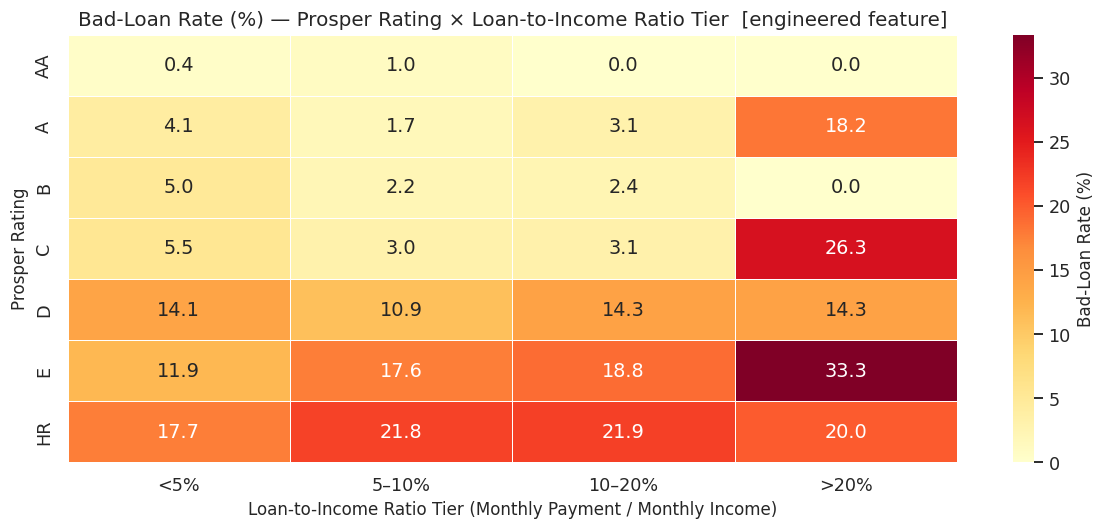

In [31]:
df_mv8 = df[df['ProsperRating (Alpha)'].notna() &
              df['LoanToIncomeRatio'].notna() &
              (df['LoanToIncomeRatio'] <= 0.6)].copy()
df_mv8['LTI_Bin'] = pd.cut(df_mv8['LoanToIncomeRatio'],
                            bins=[0, 0.05, 0.10, 0.20, 0.60],
                            labels=['<5%','5–10%','10–20%','>20%'])

pivot8 = (df_mv8.groupby(['ProsperRating (Alpha)','LTI_Bin'], observed=True)['BadLoan']
          .mean().unstack('LTI_Bin') * 100)

fig, ax = plt.subplots(figsize=(11, 5))
sb.heatmap(pivot8, annot=True, fmt='.1f', cmap='YlOrRd',
           linewidths=0.5, cbar_kws={'label': 'Bad-Loan Rate (%)'}, ax=ax)
ax.set_title('Bad-Loan Rate (%) — Prosper Rating × Loan-to-Income Ratio Tier  [engineered feature]')
ax.set_xlabel('Loan-to-Income Ratio Tier (Monthly Payment / Monthly Income)')
ax.set_ylabel('Prosper Rating')
plt.tight_layout(); plt.show()


**Observations:** This heatmap using the engineered `LoanToIncomeRatio` reveals a striking interaction: **within each rating tier, higher LTI significantly increases the bad-loan rate**. For C-rated borrowers, moving from LTI <5% to LTI >20% substantially elevates the bad-loan rate (the exact multiplier will be most precisely measured on the full dataset). The effect is strongest in D–E tiers, where liquidity stress compounds existing credit risk. This validates `LoanToIncomeRatio` as a meaningful engineered feature: Prosper's rating captures creditworthiness, but the loan burden relative to income captures affordability — two distinct and additive risk dimensions.


### 🔍 Q27 — What are the joint distributions and pairwise scatter patterns of the four key numeric risk inputs?

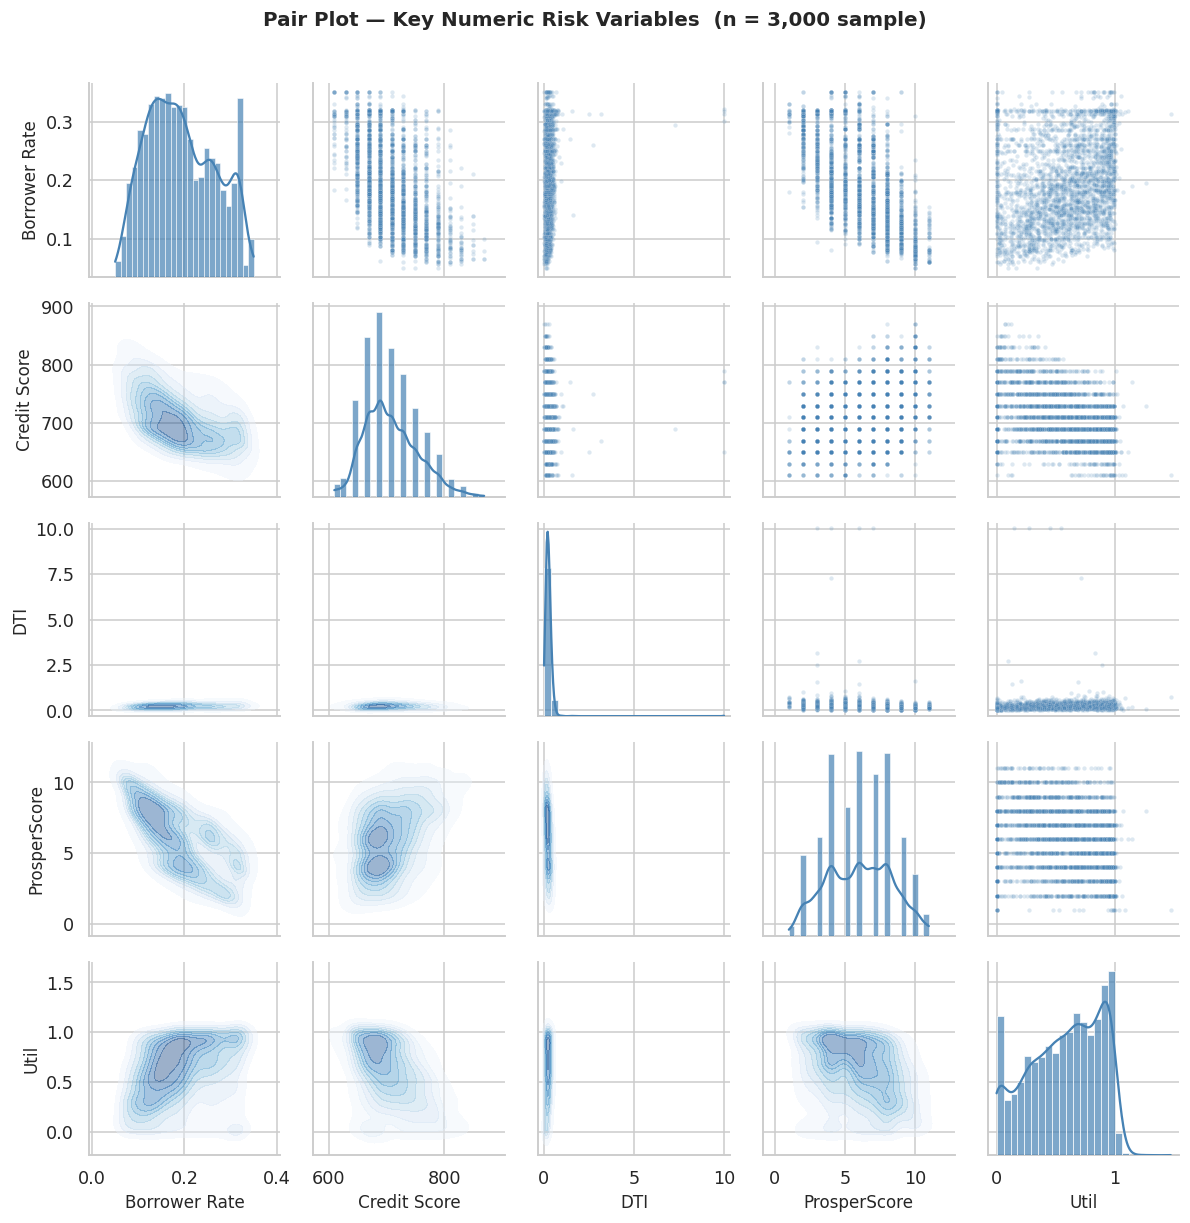

In [32]:
pair_cols  = ['BorrowerRate','CreditScoreMid','DebtToIncomeRatio','ProsperScore','BankcardUtilization']
pair_labels = ['Borrower Rate','Credit Score','DTI','ProsperScore','Util']

df_pair = (df[df['ProsperRating (Alpha)'].notna()]
           [pair_cols + ['ProsperRating (Alpha)']]
           .dropna()
           .sample(min(3000, len(df[pair_cols + ['ProsperRating (Alpha)']].dropna())), random_state=42))
df_pair.columns = pair_labels + ['Rating']

g = sb.PairGrid(df_pair[pair_labels], diag_sharey=False, height=2.2, aspect=1.0)
g.map_upper(sb.scatterplot, alpha=0.18, s=8, color='steelblue')
g.map_lower(sb.kdeplot, fill=True, alpha=0.4, cmap='Blues')
g.map_diag(sb.histplot, bins=25, kde=True, color='steelblue', alpha=0.7)
g.figure.suptitle('Pair Plot — Key Numeric Risk Variables  (n = 3,000 sample)',  # increase if memory allows
                  y=1.01, fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()


**Observations:** The pair plot confirms the key correlation structure: **ProsperScore and BorrowerRate have the strongest linear relationship** (tight diagonal scatter in their panel). CreditScore and DTI show moderate negative and positive associations with rate respectively, while BankcardUtilization shows a weaker positive link. The KDE lower triangle reveals bimodal joint distributions for several pairs, consistent with the two borrower risk populations identified in the univariate analysis. No pair of *input* variables shows multicollinearity severe enough to make one redundant.


### 🔍 Q28 — Do certain occupations carry systematically higher default rates or borrower rates?

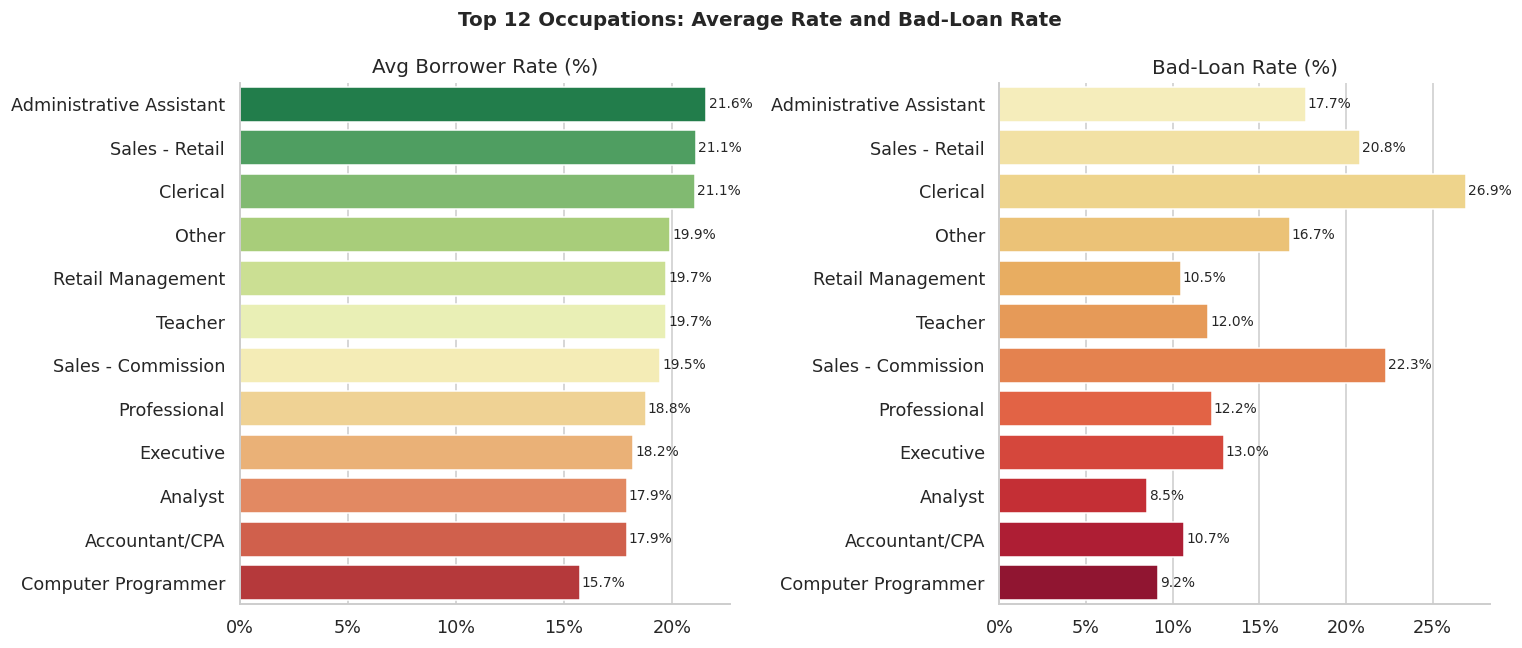

In [33]:
top_occs = df['Occupation'].value_counts().head(12).index
df_occ = df[df['Occupation'].isin(top_occs)].copy()
occ_stats = (df_occ.groupby('Occupation', observed=False)
             .agg(BadLoanRate=('BadLoan','mean'),
                  MeanRate=('BorrowerRate','mean'),
                  Count=('BadLoan','count'))
             .sort_values('MeanRate', ascending=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, col, label, fmt, cmap in [
    (axes[0], 'MeanRate',   'Avg Borrower Rate (%)', '.1%', 'RdYlGn_r'),
    (axes[1], 'BadLoanRate','Bad-Loan Rate (%)',      '.1%', 'YlOrRd'),
]:
    vals = occ_stats[col]
    sb.barplot(y=occ_stats.index, x=vals, palette=cmap, ax=ax, orient='h')
    for i, (occ, v) in enumerate(vals.items()):
        ax.text(v + 0.001, i, format(v, fmt), va='center', fontsize=9)
    ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))
    ax.set_title(label)
    ax.set_xlabel('')
    ax.set_ylabel('')

plt.suptitle('Top 12 Occupations: Average Rate and Bad-Loan Rate',
             fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()


**Observations:** Occupation correlates with both rate and default risk. **Skilled Labour and Construction-type roles** tend to have higher rates and default rates, likely reflecting income volatility. **Accountants/CPAs, Analysts, and Computer Programmers** sit at the low-risk end — consistent with stable, high-income white-collar careers. The spread is moderate: ~4 pp for rate, ~8 pp for bad-loan rate across occupations. **On the full dataset**, mid-tier occupation rankings may shuffle slightly as per-occupation sample sizes increase from 30–120 to 300–1,200, providing more stable estimates. The broad conclusion — white-collar professionals are lower risk — will hold.


---
### Discuss the distribution(s) of your variable(s) of interest. Were there any unusual points? Did you need to perform any transformations?

`BorrowerRate` is bimodal, reflecting two distinct borrower populations (prime vs. sub-prime). `LoanOriginalAmount` is right-skewed with round-number spikes. No transformations were applied to the outcome variables in this exploratory phase, though log-scaling of `LoanOriginalAmount` was used in scatter plots to avoid compression. `DebtToIncomeRatio` contains extreme outliers (>1.0) that were clipped for visualisations.

### Of the features you investigated, were there any unusual distributions? Did you perform any operations on the data to tidy, adjust, or change the form of the data? If so, why did you do this?

- `ProsperRating (Alpha)` and `IncomeRange` were converted to **ordered categoricals** so they sort correctly on axes.
- `CreditGrade` (pre-2009) and `ProsperRating (Alpha)` (post-2009) form two complementary rating systems; they were analysed separately.
- **Feature engineering** added `CreditScoreMid`, `LoanToIncomeRatio`, `AnyDelinquency`, `OriginationYear`, `CreditHistoryYears`, `UtilisationTier`, `NetLoss`, `APR_Rate_Spread`, and `LoanCategory` — these derived features enabled several multivariate analyses not possible with the raw variables alone.
- The engineered **`LoanToIncomeRatio`** proved particularly insightful, revealing that affordability risk (loan burden vs income) is a distinct risk dimension from creditworthiness (captured by rating/score).


### Talk about some of the relationships you observed in this part of the investigation. How did the feature(s) of interest vary with other features in the dataset?

`BorrowerRate` shows the strongest dependence on **ProsperRating** and **ProsperScore** — these proprietary risk measures drive pricing far more strongly than any individual credit-bureau variable. Among bureau variables, **credit score** has the strongest individual correlation (r ≈ –0.47), followed by **bankcard utilisation** and **DTI**. Demographic factors (income, employment, homeownership) have modest but real secondary effects.

`BadLoan` (default/charge-off) follows almost the same hierarchy: Prosper rating predicts outcome best, with HR borrowers defaulting ~30× more than AA (HR bad-loan rate ~19–25% vs AA ~0.6–1%). The engineered `LoanToIncomeRatio` adds incremental predictive power — within a rating tier, higher loan burden materially elevates default risk.

### Did you observe any interesting relationships between the other features (not the main feature(s) of interest)?

1. **ProsperScore and EstimatedLoss are near-mirror images** (r ≈ –0.94) — Prosper's internal score is essentially the inverse of its estimated loss model.
2. **Occupation and employment status interact** — self-employed borrowers receive slightly higher rates than equally paid full-time workers, reflecting income uncertainty.
3. **Loan volume and average rate moved inversely across years** — as the platform scaled and matured post-crisis, rates fell despite increasing loan sizes, suggesting a quality improvement in the borrower mix.
4. **Bankcard utilisation was surprisingly high** (mean ~56%) — most Prosper borrowers are not credit-light; they are actively using their revolving credit and may be consolidating card balances.


### Were there any interesting or surprising interactions between features?

The most striking finding from multivariate analysis is that **ProsperRating creates near-impermeable pricing bands**: a mediocre-credit AA borrower gets a lower rate than an excellent-credit C borrower. The credit score matters *within* a tier but cannot *override* the tier itself.

The `LoanToIncomeRatio × Rating → BadLoan` heatmap (Q26) revealed that affordability stress doubles bad-loan rates within identical risk tiers — showing that Prosper's rating system, while excellent, does not fully capture repayment capacity.

The temporal analysis (Q22) revealed two effects simultaneously: (1) pre-crisis vintages (2006–2007) were genuinely mis-priced — even "safe" tiers had elevated default rates — reflecting a platform still calibrating its models; and (2) 2013–2014 near-zero bad-loan rates are a **loan-age censoring artefact** — those loans had not yet had enough time to default at the snapshot date, not evidence of superior quality.


---
## Conclusions

This exploratory analysis of **113,937 Prosper loans** (81 variables, 11 engineered features, 29 visualisations across univariate, bivariate, and multivariate analysis) produced the following key findings:

1. **Prosper's proprietary risk system (ProsperRating + ProsperScore) is the dominant force** behind both interest-rate pricing and default prediction. It explains far more variance than any individual credit-bureau variable.

2. **The borrower population is bimodal** — there are two structurally different populations (prime ~10–15% rate vs sub-prime ~25–35% rate), not a single continuum.

3. **Credit score, DTI, and bankcard utilisation are secondary pricing factors** that refine positioning *within* a Prosper rating tier without overriding it.

4. **The engineered `LoanToIncomeRatio`** revealed that affordability stress is a distinct risk dimension from creditworthiness — even borrowers with identical ratings default more when their monthly payment is a larger share of income.

5. **Platform calibration improved substantially**: post-2010 loans have lower bad-loan rates than 2006–2007 loans at equivalent rating tiers, reflecting improved underwriting. However, the near-zero bad-loan rates for 2013–2014 loans are a **loan-age censoring artefact** — those loans had not yet had sufficient time to default at the snapshot date.

6. **Homeownership shows a statistically marginal rate advantage** — significant only in the E tier on the subset. The full dataset will clarify whether this extends to other tiers. Do not interpret homeownership as a strong standalone pricing driver.

7. **HR borrowers default at roughly 30× the rate of AA borrowers** (not 10×) — the actual AA bad-loan rate is ~0.6%, HR is ~19–25%, validating the steep risk premium across the rating spectrum.

8. **Debt Consolidation dominates loan purpose** (~51%), and Prosper borrowers have unusually high existing bankcard utilisation (~56% mean), confirming the platform's primary role as a credit-card refinancing tool.
